# 12. Why do the toy test-statistic distributions differ?

Diagnose the notebook 11 results at **\(\mu=0\) and \(1.4\)** without
changing the physics model or trained networks. We separate competing
likelihood minima, numerical minimization, integration error, and
finite-bin compression. All fits remain **stat-only** and use the same
two-sided \(q_\mu=-2\log[L(\mu)/L(\hat\mu)]\).

| Stage | Question | Additional cost |
|---|---|---|
| Saved-record analysis | Does a different minimum explain the paired \(q_\mu\) differences? | Tables and plots only |
| Coverage bootstrap | How uncertain are the empirical calibration thresholds and their transfer? | Resampling existing toy records |
| Independent integration | Do simulator bin means and expected scores agree with the frozen model? | New integration proposals and frozen preselection |
| Paired refits | Does the result change with finer minimization, wider bounds, more bins, or new integrals? | Reconstructed selected experiments and fits |

A different test-statistic distribution from the analytical benchmark
is not by itself a calibration failure. For calibration, compare each
fitted model's own-toy distribution with its simulator-toy distribution.

### Reuse the completed notebook 11 run

Keep **`RUN_NAME = "paper-distinct-s-v4"`**, the same `MODE`, and the same
`CONFIG_OVERRIDES` used in notebook 11. No regeneration, retraining, or rerunning
01–11 is required. This notebook reads notebook 11's completed toy records and
frozen model, then writes its own diagnostics to a separate directory. It never
extends or overwrites the notebook 11 ensemble.

Start a fresh Colab runtime so the setup loads the updated source. If reusing a
runtime, refresh its temporary `/content/poodemo` checkout and restart first;
your saved Google Drive run is separate. The setup reuses the repository's
normal private-repository authentication and Drive mount. Select a GPU runtime
for the later stages: neural preselection and ratio evaluation benefit from it,
while the small likelihood fits run on the CPU.

The **first stage uses saved tables only**, without loading trained networks or
creating new events. Set `RUN_INTEGRATION = False` and `RUN_REFITS = False` for
that inexpensive first look. The default enables all stages; the settings below
control their computational budgets independently. `MODE="smoke"` refers to an
existing smoke run with its own completed notebook 11 outputs.

In [2]:
import os
import sys
from pathlib import Path

RUN_NAME = "paper-distinct-s-v4"
MODE = os.environ.get("POODEMO_MODE", "production")  # production or smoke
CONFIG_OVERRIDES = {}  # e.g. {"quadrature_per_process": 500_000, "epochs": 150}
JAX_BACKEND = os.environ.get("POODEMO_JAX_BACKEND", "auto")  # auto, gpu, or cpu

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    requested_backend = JAX_BACKEND.strip().lower()
    if requested_backend not in ("auto", "gpu", "cpu"):
        raise ValueError("JAX_BACKEND must be auto, gpu, or cpu")
    selected_backend = requested_backend
    if requested_backend == "auto":
        try:
            gpu_probe = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                                       capture_output=True, text=True, timeout=10)
            gpu_present = gpu_probe.returncode == 0 and bool(gpu_probe.stdout.strip())
        except (OSError, subprocess.TimeoutExpired):
            gpu_present = False
        selected_backend = "gpu" if gpu_present else "cpu"
    # CUDA-only selection fails visibly if initialization fails. Keep PyTorch's
    # CUDA visibility and avoid JAX reserving most GPU memory before training.
    jax_platform = "cuda" if selected_backend == "gpu" else "cpu"
    os.environ["JAX_PLATFORMS"] = jax_platform
    os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    ROOT = Path(os.environ.get("POODEMO_ROOT", f"/content/drive/MyDrive/poodemo/runs/{RUN_NAME}"))
    REPO_DIR = Path("/content/poodemo")
    if not (REPO_DIR / "pyproject.toml").exists():
        import getpass
        import io
        import shutil
        import tarfile
        import tempfile
        import urllib.error
        import urllib.request
        import zipfile

        uploaded_zip = Path("/content/poodemo_source.zip")
        if uploaded_zip.exists():
            archive_bytes = uploaded_zip.read_bytes()
            archive_kind = "zip"
        else:
            archive_url = "https://api.github.com/repos/rafaellopesdesa/poodemo/tarball/main"

            def fetch_source(token=None):
                headers = {"Accept": "application/vnd.github+json", "User-Agent": "poodemo-colab"}
                if token:
                    headers["Authorization"] = "Bearer " + token
                request = urllib.request.Request(archive_url, headers=headers)
                with urllib.request.urlopen(request, timeout=180) as response:
                    return response.read()

            try:
                archive_bytes = fetch_source()
            except urllib.error.HTTPError as error:
                if error.code not in (401, 403, 404):
                    raise RuntimeError(f"Repository download failed (HTTP {error.code}).") from None
                token = None
                try:
                    from google.colab import userdata
                    token = userdata.get("GITHUB_TOKEN")
                except Exception:
                    pass
                if not token:
                    token = getpass.getpass("GitHub token with read access to poodemo: ").strip()
                if not token:
                    raise RuntimeError("Upload /content/poodemo_source.zip or provide read access.")
                try:
                    archive_bytes = fetch_source(token)
                except urllib.error.HTTPError as auth_error:
                    raise RuntimeError(f"Repository download failed (HTTP {auth_error.code}); check token access.") from None
                finally:
                    token = None
            archive_kind = "tar"

        # Validate archive paths and reject links before extracting the source.
        with tempfile.TemporaryDirectory(prefix="poodemo-source-") as temp:
            staging = Path(temp).resolve()

            def safe_destination(name):
                destination = (staging / name).resolve()
                if not destination.is_relative_to(staging):
                    raise RuntimeError("Unsafe path in source archive.")
                return destination

            if archive_kind == "zip":
                with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
                    for entry in archive.infolist():
                        safe_destination(entry.filename)
                        if (entry.external_attr >> 16) & 0o170000 == 0o120000:
                            raise RuntimeError("Symbolic links are not supported in the source ZIP.")
                    archive.extractall(staging)
            else:
                with tarfile.open(fileobj=io.BytesIO(archive_bytes), mode="r:gz") as archive:
                    for entry in archive.getmembers():
                        safe_destination(entry.name)
                        if not (entry.isfile() or entry.isdir()):
                            raise RuntimeError("Links and special files are not supported in the source archive.")
                    archive.extractall(staging)
            candidates = [p.parent for p in staging.rglob("pyproject.toml") if (p.parent / "poodemo").is_dir()]
            if len(candidates) != 1:
                raise RuntimeError("The uploaded archive must contain one poodemo repository checkout.")
            shutil.copytree(candidates[0], REPO_DIR, dirs_exist_ok=True)
        del archive_bytes

    if os.environ.get("POODEMO_SKIP_INSTALL") != "1":
        from importlib.metadata import version, PackageNotFoundError
        # JAX discovers every installed plugin, even when selecting CPU.
        # Retain already-matched CUDA 12 packages when rerunning GPU setup.
        remove_plugins = []
        for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt", "jax-cuda13-plugin", "jax-cuda13-pjrt"):
            try:
                installed_version = version(package)
            except PackageNotFoundError:
                continue
            if not (selected_backend == "gpu" and package.startswith("jax-cuda12-") and installed_version == "0.5.3"):
                remove_plugins.append(package)
        if remove_plugins:
            subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", *remove_plugins])
        gpu_requirements = (["jax==0.5.3", "jaxlib==0.5.3",
                             "jax-cuda12-plugin[with-cuda]==0.5.3", "jax-cuda12-pjrt==0.5.3"]
                            if selected_backend == "gpu" else [])
        # Resolve with the base requirements so PyTorch's CUDA dependencies are
        # considered together with JAX's. Avoid blanket --upgrade changes.
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r",
                               str(REPO_DIR / "requirements-colab.txt"), *gpu_requirements])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)])

        # Check the live notebook kernel before any expensive network training.
        import jax
        import jaxlib
        import jax.numpy as jnp
        if jax.__version__ != "0.5.3" or jaxlib.__version__ != "0.5.3":
            raise RuntimeError("JAX packages are stale in this kernel. Restart the runtime and rerun setup.")
        if selected_backend == "gpu":
            for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt"):
                if version(package) != "0.5.3":
                    raise RuntimeError(f"{package} must match JAX 0.5.3. Restart the runtime and rerun setup.")
        jax.config.update("jax_platforms", jax_platform)
        jax.config.update("jax_enable_x64", True)
        try:
            jax_devices = jax.devices()
            if not jax_devices or any(device.platform != selected_backend for device in jax_devices):
                raise RuntimeError(f"Expected {selected_backend} devices; found {jax_devices}")
            probe_value, probe_gradient = jax.jit(jax.value_and_grad(lambda x: jnp.sum(x*x)))(
                jnp.asarray([1., 2., 3.], dtype=jnp.float64))
            probe_gradient.block_until_ready()
            if (float(probe_value) != 14. or list(probe_gradient) != [2., 4., 6.]
                    or probe_gradient.dtype != jnp.float64
                    or any(device.platform != selected_backend for device in probe_gradient.devices())):
                raise RuntimeError("JAX double-precision value/gradient check failed")
        except Exception as error:
            raise RuntimeError(
                f"JAX {selected_backend} startup failed. Select a Colab GPU runtime if requesting GPU, "
                "then restart the runtime and rerun setup. Use JAX_BACKEND='cpu' only for an intentional CPU run."
            ) from error
        print(f"JAX {jax.__version__} / jaxlib {jaxlib.__version__}: backend={selected_backend}, {jax_devices}; float64 JIT/gradient OK")

    # A new editable install is not activated in an already-running kernel.
    # Expose the inner package directly, including after a failed import cached
    # the outer /content/poodemo checkout as a namespace package.
    import importlib
    source_root = str(REPO_DIR.resolve())
    if source_root in sys.path:
        sys.path.remove(source_root)
    sys.path.insert(0, source_root)
    importlib.invalidate_caches()
    cached_package = sys.modules.get("poodemo")
    cached_file = getattr(cached_package, "__file__", None)
    expected_init = REPO_DIR / "poodemo" / "__init__.py"
    if cached_package is not None and (cached_file is None or Path(cached_file).resolve() != expected_init.resolve()):
        for module_name in list(sys.modules):
            if module_name == "poodemo" or module_name.startswith("poodemo."):
                del sys.modules[module_name]
else:
    # Locally: pip install -r requirements-colab.txt && pip install -e .
    ROOT = Path(os.environ.get("POODEMO_ROOT", str(Path.home() / "poodemo-runs" / RUN_NAME)))
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "poodemo" / "pipeline.py").exists():
            sys.path.insert(0, str(candidate))
            break

ROOT.mkdir(parents=True, exist_ok=True)
print(f"Run directory: {ROOT}")
print(f"Mode: {MODE}")

Mounted at /content/drive


/tmp/ipykernel_3277/3728892442.py:110: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(staging)


JAX 0.5.3 / jaxlib 0.5.3: backend=gpu, [CudaDevice(id=0)]; float64 JIT/gradient OK
Run directory: /content/drive/MyDrive/poodemo/runs/paper-distinct-s-v4
Mode: production


In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from poodemo.pipeline import create_run

run = create_run(ROOT, mode=MODE, overrides=CONFIG_OVERRIDES)
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.2})
display(pd.Series(run.config, name="configuration"))


import mplhep as hep
hep.style.use("ATLAS")
# Typography and ticks only; no ATLAS label.
plt.rcParams.update({"axes.grid": False, "figure.dpi": 110})

,configuration
schema_version,7
mode,production
seed,20261006
physics_overrides,{}
toolkit_commit,fc09848fc6540fd32310faebbe9db6eea7ecd17b
n_per_sample,5000000
ni_sample_multiplier,10
generation_chunk,250000
preselection_train_cap,1000000
ratio_train_cap,2000000


### Settings and computational budgets

The original exposure, tested hypotheses, observable power, random seed,
and 12-bin definition are read from the saved notebook 11 metadata.
The \(\eta=\mu_{\rm test}\) observable and its normalization constants
stay frozen during every fit and integration comparison.

Defaults use 1,000 coverage bootstrap replicates; two independent banks
at each of 1, 2, and 5 times the original generated sample size; and a
random sample of 200 experiments per hypothesis, plus all flagged toys.
A flag selects an experiment for which at least one fit reaches the
original upper bound. The flagged collection can substantially exceed
200 experiments. Set `MAX_FLAGGED_TOYS` to a finite number if necessary;
the selected toy IDs are saved for reproducibility.

Matching heavy-stage checkpoints are reused. If changing integration
settings, refit selection, fit bounds, or whether independent templates
are used, choose a new `OUTPUT_TAG`; incompatible cached calculations
are rejected rather than mixed.

`BRANCH_SPLIT=1` is a descriptive threshold separating the low- and
high-\(\mu\) solutions. It is not a new physical bound or an optimizer
setting. At truth 1.4 the high branch is the branch containing the truth.

In [4]:
from poodemo.toy_diagnostics import (
    load_toy_study, analyze_paired_toys, plot_paired_toys,
    bootstrap_coverage, plot_bootstrap_coverage,
)

SOURCE_TAG = "toy_study_direct"  # Completed notebook 11 ensemble.
OUTPUT_TAG = "toy_diagnostics"  # Separate from notebook 11 outputs.
BRANCH_SPLIT = 1.0  # Operational low/high-mu branch definition, not a fit constraint.
COVERAGE_LEVELS = (0.68, 0.95)
N_BOOTSTRAP = 100 if MODE == "smoke" else 1000
BOOTSTRAP_SEED = 120424

RUN_INTEGRATION = True
BASE_GENERATED_PER_SOURCE = None  # None uses the original quadrature manifest.
BANK_MULTIPLES = (1, 2, 5)
BANK_REPLICAS = 2
INTEGRATION_SEED = 120524
GENERATION_CHUNK_SIZE = 100_000

RUN_REFITS = True
N_RANDOM_TOYS = 3 if MODE == "smoke" else 200  # Per tested hypothesis.
MAX_FLAGGED_TOYS = None  # None keeps every flagged toy, in addition to the random sample.
REFIT_SELECTION_SEED = 120624
WIDE_MU_BOUNDS = (0.0, 3.0)
DENSE_FIT_GRID_SIZE = 129  # Grid in kappa=sqrt(mu), plus local refinement.
BIN_COUNTS = (12, 36)  # 36 subdivides each of the original 12 bins into three.
N_LIKELIHOOD_SCANS = 3
PROGRESS_EVERY = 10

DIAGNOSTIC_DIR = ROOT / "results" / "12_toy_diagnostics" / OUTPUT_TAG
FIGURE_DIR = ROOT / "plots" / "12_toy_diagnostics" / OUTPUT_TAG
DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def show_figures(figures):
    for name, figure in figures.items():
        print(name)
        display(figure)
        plt.close(figure)


def show_tables(result, *, max_rows=20):
    for name, frame in result.items():
        if isinstance(frame, pd.DataFrame):
            print(f"{name}: {len(frame):,} rows")
            display(frame.head(max_rows))


print("Source ensemble:", SOURCE_TAG)
print("Diagnostic tables:", DIAGNOSTIC_DIR)
print("Integration stage:", RUN_INTEGRATION, "| Refit stage:", RUN_REFITS)

Source ensemble: toy_study_direct
Diagnostic tables: /content/drive/MyDrive/poodemo/runs/paper-distinct-s-v4/results/12_toy_diagnostics/toy_diagnostics
Integration stage: True | Refit stage: True


### 1. Pair the existing simulator experiments

The analytical, learned, and binned fits share each physical simulator
experiment. Pair by **tested hypothesis and toy ID**, retaining failure
flags, rather than comparing independent histogram fluctuations.

Inspect \(\hat\mu_{\rm binned}\) versus \(\hat\mu_{\rm analytic}\), then
\(\Delta q=q_{\rm binned}-q_{\rm analytic}\) within each pair of branches.
A concentration of large differences in branch-disagreeing experiments
would support the competing-minimum explanation. Comparisons within
the same branch check whether that explanation is sufficient.

In [5]:
source = load_toy_study(run, source_tag=SOURCE_TAG)
print("Notebook 11 provenance and settings:")
display(pd.Series(source["metadata"]))
print("Completeness by hypothesis and case (including missing and failed records):")
display(source["completeness"])
source["completeness"].to_csv(DIAGNOSTIC_DIR / "source_completeness.csv", index=False)
print("Failed fits remain in the diagnostics; they are not silently treated as valid.")
with (DIAGNOSTIC_DIR / "saved_table_analysis.json").open("w") as handle:
    json.dump({"source_tag": SOURCE_TAG,
               "source_results_sha256": source["results_sha256"],
               "source_config_sha256": source["config_sha256"],
               "branch_split": BRANCH_SPLIT,
               "n_bootstrap": N_BOOTSTRAP,
               "bootstrap_seed": BOOTSTRAP_SEED,
               "coverage_levels": COVERAGE_LEVELS}, handle, indent=2)

Notebook 11 provenance and settings:


,0
configuration,"{'version': 2, 'statistic': 'two-sided q_mu; e..."
fingerprint,75f306456f9963c0c5a510e198c2ca7afa024ee939b211...
requested_toys_per_hypothesis,5000
source_diagnostics,{'0.0': {'source': 'finite_quadrature_poisson_...
simulation_note,Fresh continuous physical Poisson events with ...
learned_source_note,Poisson sampling from finite quadrature weight...
normalization_note,All fitted integrals and observable normalizer...
fit_note,"All minima resolved by a grid in sqrt(mu), the..."
coverage_note,Even self-model toy IDs calibrate critical val...
validity_note,Learned intensities are checked on the quadrat...


Completeness by hypothesis and case (including missing and failed records):


,mu_test,case,requested,n_present,n_valid,n_failed,n_missing
0,0.0,analytic_simulator,5000,5000,5000,0,0
1,0.0,learned_simulator,5000,5000,5000,0,0
2,0.0,learned_model,5000,5000,5000,0,0
3,0.0,binned_simulator,5000,5000,5000,0,0
4,0.0,binned_model,5000,5000,5000,0,0
5,1.4,analytic_simulator,5000,5000,5000,0,0
6,1.4,learned_simulator,5000,5000,5000,0,0
7,1.4,learned_model,5000,5000,5000,0,0
8,1.4,binned_simulator,5000,5000,5000,0,0
9,1.4,binned_model,5000,5000,5000,0,0


Failed fits remain in the diagnostics; they are not silently treated as valid.


paired: 20,000 rows


,mu_test,toy_id,analytic_q,analytic_mu_hat,analytic_valid,analytic_at_lower,analytic_at_upper,analytic_present,comparison_q,comparison_mu_hat,...,comparison_case,paired_valid,delta_q,analytic_branch,analytic_remote,analytic_zero_q,comparison_branch,comparison_remote,comparison_zero_q,branch_group
0,0.0,0,0.000000,0.000000,True,True,False,True,0.000000,0.000000,...,learned_simulator,True,0.000000,low,False,True,low,False,True,same_near_truth
1,0.0,1,0.000000,0.000000,True,True,False,True,0.000000,0.000000,...,learned_simulator,True,0.000000,low,False,True,low,False,True,same_near_truth
2,0.0,2,0.090032,0.000128,True,False,False,True,0.016000,0.000022,...,learned_simulator,True,-0.074033,low,False,False,low,False,False,same_near_truth
3,0.0,3,11.800315,1.830691,True,False,False,True,6.976040,1.833903,...,learned_simulator,True,-4.824274,high,True,False,high,True,False,both_remote
4,0.0,4,0.000000,0.000000,True,True,False,True,10.523194,1.801748,...,learned_simulator,True,10.523194,low,False,True,high,True,False,only_comparison_remote
5,0.0,5,1.029982,0.001514,True,False,False,True,0.939679,0.001371,...,learned_simulator,True,-0.090303,low,False,False,low,False,False,same_near_truth
6,0.0,6,0.508689,0.000743,True,False,False,True,0.426214,0.000618,...,learned_simulator,True,-0.082475,low,False,False,low,False,False,same_near_truth
7,0.0,7,0.000000,0.000000,True,True,False,True,0.000000,0.000000,...,learned_simulator,True,0.000000,low,False,True,low,False,True,same_near_truth
8,0.0,8,0.000000,0.000000,True,True,False,True,0.000000,0.000000,...,learned_simulator,True,0.000000,low,False,True,low,False,True,same_near_truth
9,0.0,9,0.241672,0.000346,True,False,False,True,0.232050,0.000331,...,learned_simulator,True,-0.009622,low,False,False,low,False,False,same_near_truth


summary: 4 rows


,mu_test,comparison_case,n_requested,n_paired_valid,n_invalid_or_missing,n_analytic_missing,n_comparison_missing,n_analytic_failed,n_comparison_failed,mean_delta_q,paired_se_delta_q,median_delta_q,mean_absolute_delta_q,branch_disagreement_fraction,analytic_zero_q_fraction,comparison_zero_q_fraction,zero_q_fraction_difference,paired_se_zero_q_difference
0,0.0,learned_simulator,5000,5000,0,0,0,0,0,0.078257,0.013889,0.000000,0.252387,0.0488,0.5664,0.5744,0.0080,0.003297
1,1.4,learned_simulator,5000,5000,0,0,0,0,0,0.184483,0.011724,0.053530,0.321057,0.0458,0.0000,0.0000,0.0000,0.000000
2,0.0,binned_simulator,5000,5000,0,0,0,0,0,0.291028,0.020506,0.000000,0.568107,0.1490,0.5664,0.4732,-0.0932,0.005624
3,1.4,binned_simulator,5000,5000,0,0,0,0,0,0.048091,0.007383,0.006883,0.198375,0.0304,0.0000,0.0000,0.0000,0.000000


branch_summary: 16 rows


,mu_test,comparison_case,branch_group,n_paired,fraction_of_valid_pairs,fraction_se,mean_delta_q,paired_se_delta_q
0,0.0,learned_simulator,same_near_truth,4569,0.9138,0.003969,-0.028063,0.001166
1,0.0,learned_simulator,only_comparison_remote,179,0.0358,0.002627,2.615336,0.166533
2,0.0,learned_simulator,only_analytic_remote,65,0.0130,0.001602,-2.075101,0.241681
3,0.0,learned_simulator,both_remote,187,0.0374,0.002683,0.995950,0.240031
4,1.4,learned_simulator,same_near_truth,4665,0.9330,0.003536,0.080992,0.003491
5,1.4,learned_simulator,only_comparison_remote,180,0.0360,0.002635,2.220038,0.142830
6,1.4,learned_simulator,only_analytic_remote,49,0.0098,0.001393,-1.516711,0.197062
7,1.4,learned_simulator,both_remote,106,0.0212,0.002037,2.068880,0.315464
8,0.0,binned_simulator,same_near_truth,4106,0.8212,0.005419,0.035071,0.004575
9,0.0,binned_simulator,only_comparison_remote,642,0.1284,0.004731,2.474198,0.083392


paired_mu_hat


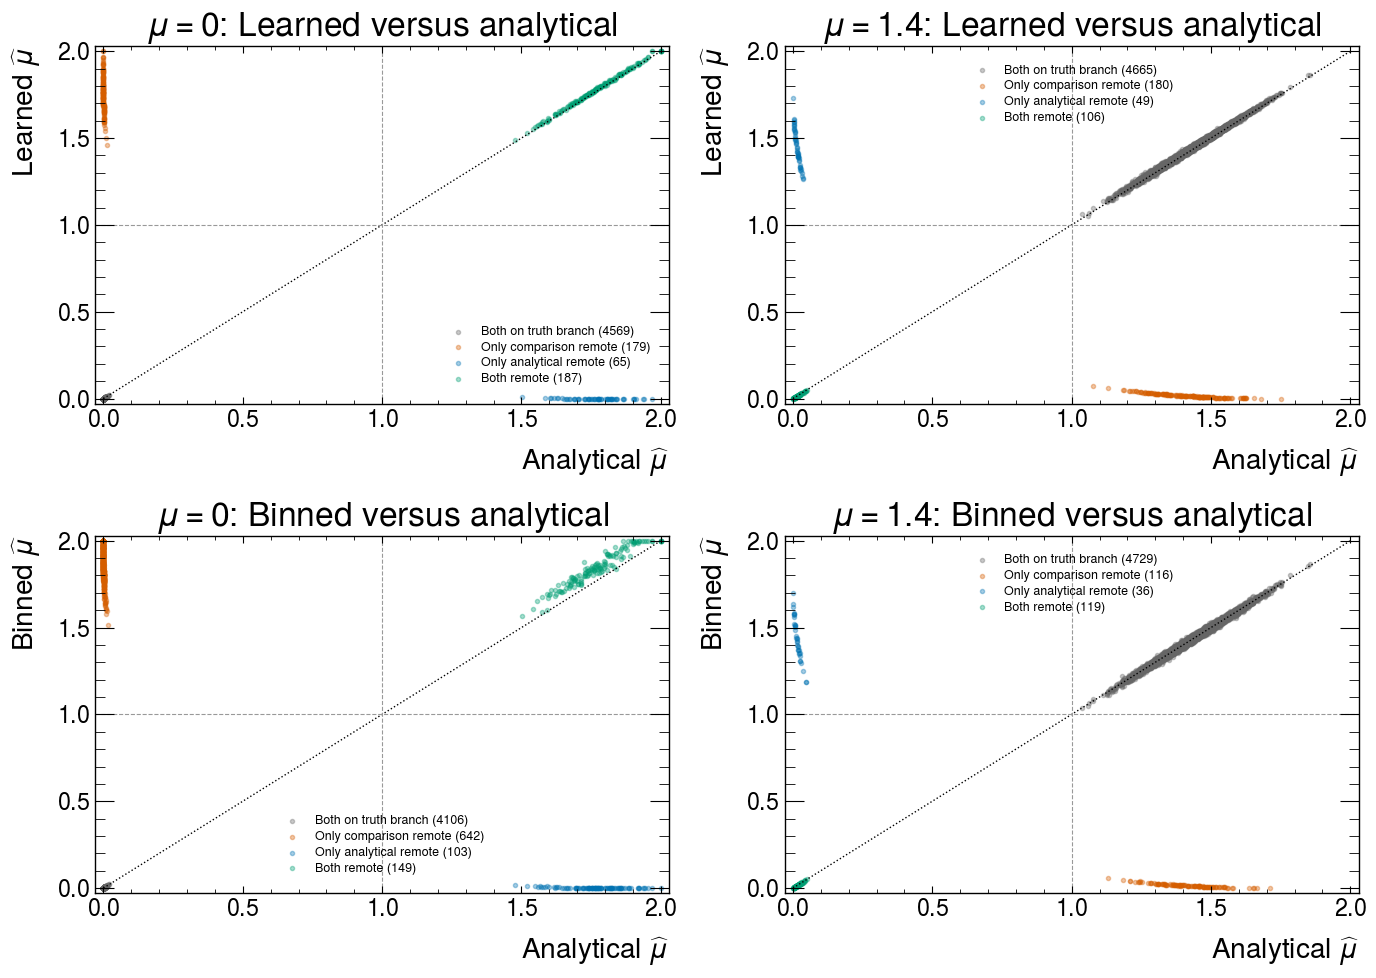

paired_delta_q


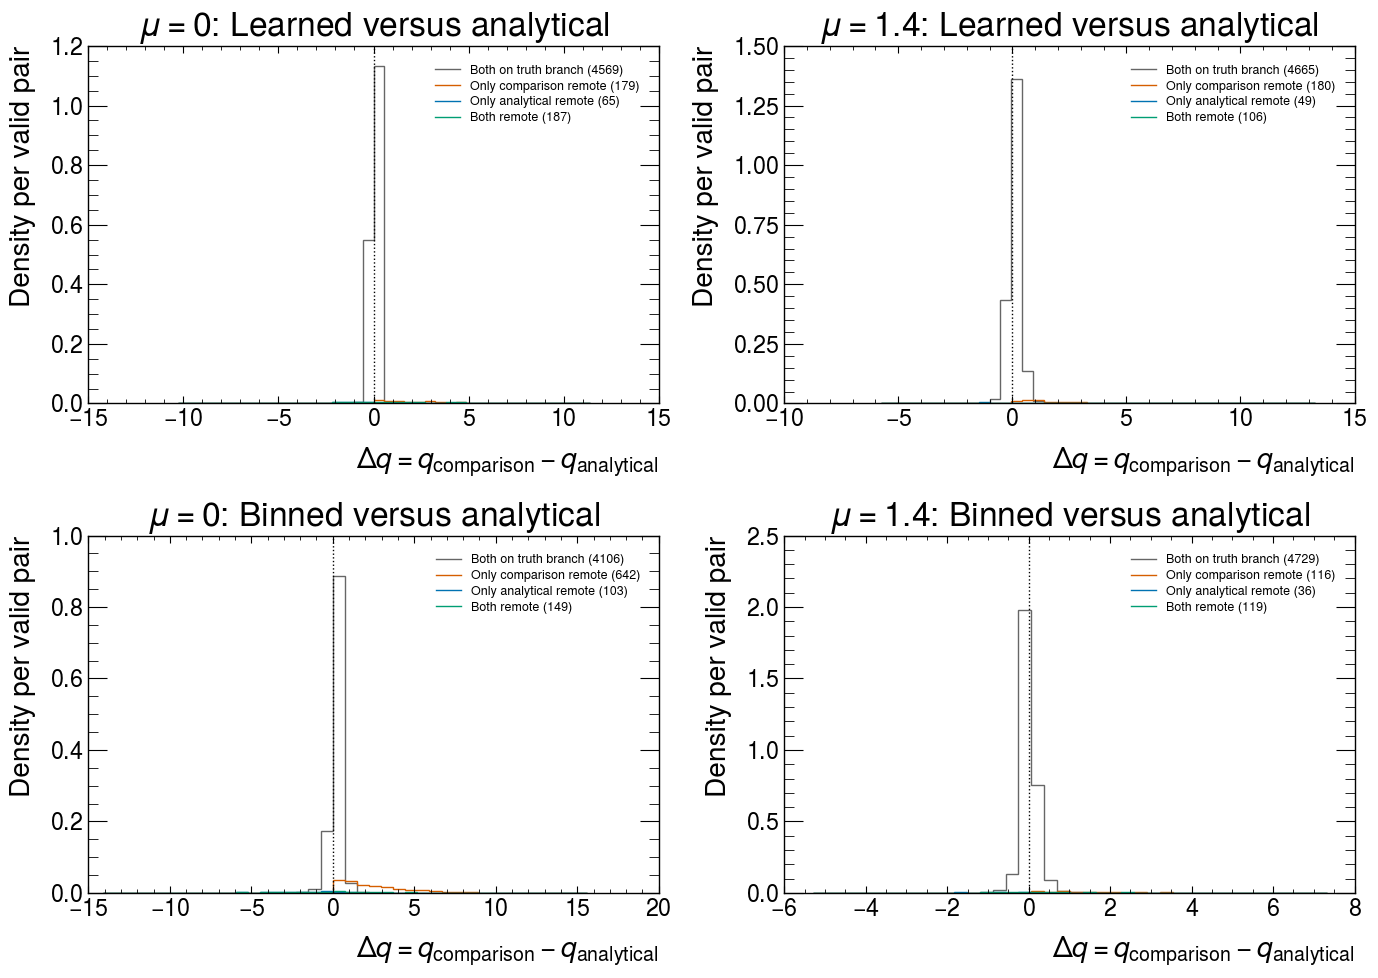

branch_q_survival


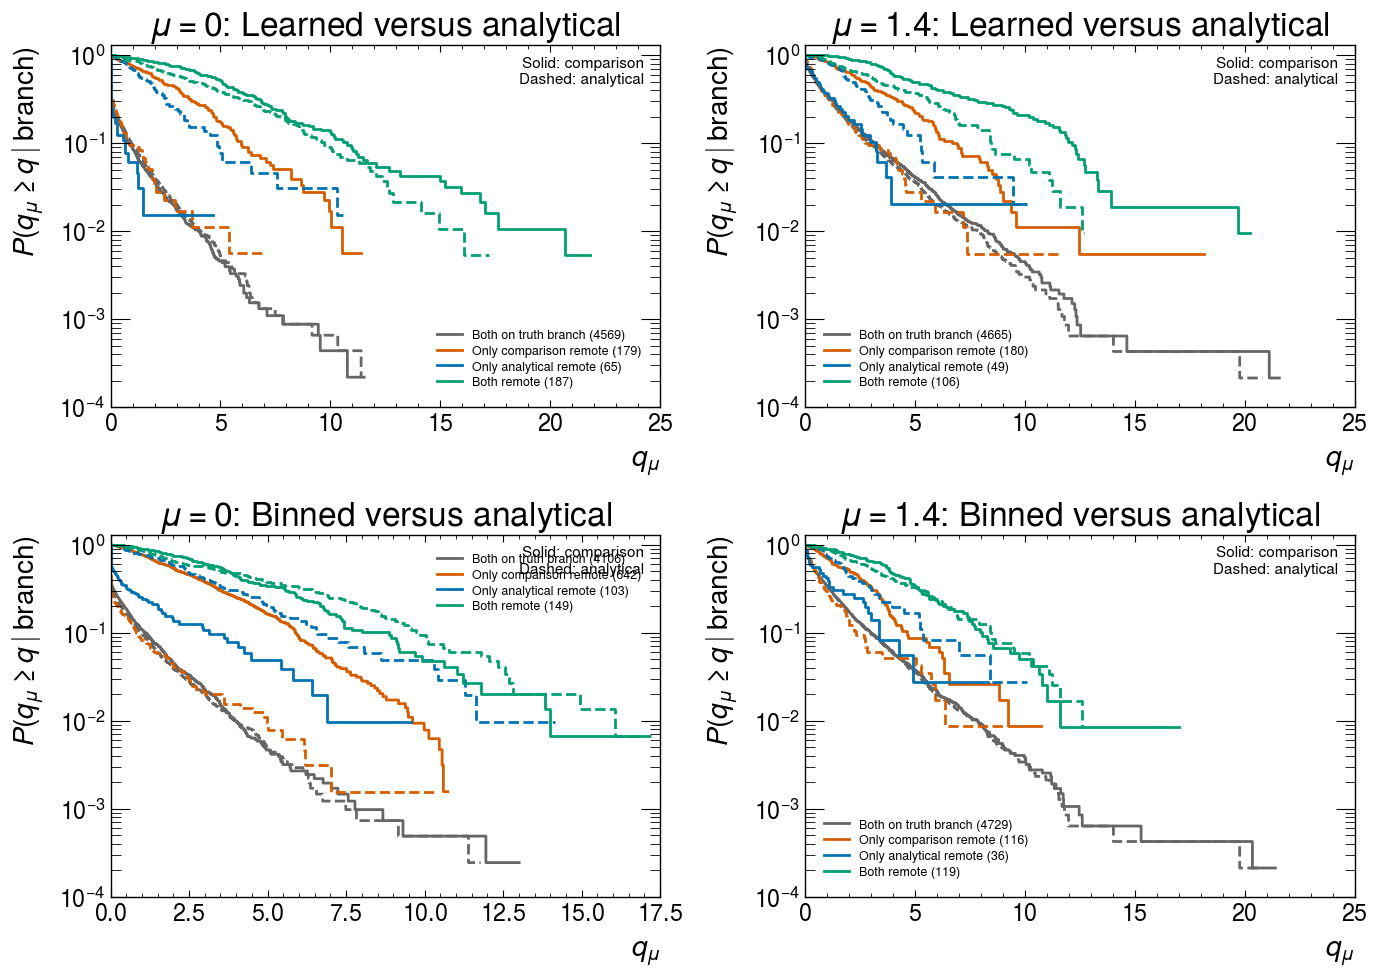

In [6]:
paired = analyze_paired_toys(source, branch_split=BRANCH_SPLIT)
for name, frame in paired.items():
    if isinstance(frame, pd.DataFrame):
        frame.to_csv(DIAGNOSTIC_DIR / f"paired_{name}.csv", index=False)
show_tables(paired)
show_figures(plot_paired_toys(paired, output=FIGURE_DIR / "paired"))

### 2. Include calibration-threshold uncertainty

Recompute the model-toy critical values and the simulator acceptance in
each bootstrap replicate. Resample **whole toy IDs**, sharing a draw
across methods whose experiments are paired, while keeping notebook 11's
disjoint calibration and evaluation partitions. This incorporates the
finite ensemble uncertainty of the critical value as well as the
evaluation fraction.

Interpret the results as uncertainty conditional on the saved model and
integration bank. They do not include finite-MC uncertainty in its
templates or in the trained ratios. At \(\mu=0\), the point mass at
\(q=0\) makes empirical quantiles discontinuous and nonrandomized
acceptance can be conservative; bootstrap intervals are a diagnostic,
not an exact coverage guarantee. The extreme log-scale tail remains
limited by the number of available toys.

,mu_test,case,label,nominal,calibration_case,critical_q,critical_bootstrap_se,coverage,binomial_se,bootstrap_se,...,difference_ci_high,n_calibration,n_calibration_failed,n_calibration_missing,n_evaluation,n_evaluation_failed,n_evaluation_missing,failure_lower_bound,failure_upper_bound,conditioning
0,0.0,analytic_simulator,Analytical / simulator,0.68,analytic_simulator,0.094862,0.017489,0.6828,0.009308,0.013578,...,0.00000,2500,0,0,2500,0,0,0.6828,0.6828,valid fits; missing/failed fits shown separately
1,0.0,analytic_simulator,Analytical / simulator,0.95,analytic_simulator,2.820911,0.214972,0.9560,0.004102,0.006025,...,0.00000,2500,0,0,2500,0,0,0.9560,0.9560,valid fits; missing/failed fits shown separately
2,0.0,learned_simulator,Learned / simulator,0.68,learned_model,0.262768,0.025256,0.7468,0.008697,0.010753,...,0.09320,2500,0,0,2500,0,0,0.7468,0.7468,valid fits; missing/failed fits shown separately
3,0.0,learned_simulator,Learned / simulator,0.95,learned_model,3.048134,0.129175,0.9408,0.004720,0.005436,...,-0.00080,2500,0,0,2500,0,0,0.9408,0.9408,valid fits; missing/failed fits shown separately
4,0.0,learned_model,Learned / learned bank,0.68,learned_model,0.262768,0.025256,0.6772,0.009351,0.012128,...,0.00000,2500,0,0,2500,0,0,0.6772,0.6772,valid fits; missing/failed fits shown separately
5,0.0,learned_model,Learned / learned bank,0.95,learned_model,3.048134,0.129175,0.9548,0.004155,0.004917,...,0.00000,2500,0,0,2500,0,0,0.9548,0.9548,valid fits; missing/failed fits shown separately
6,0.0,binned_simulator,Binned / simulator,0.68,binned_model,0.527840,0.039433,0.7152,0.009026,0.013114,...,0.07640,2500,0,0,2500,0,0,0.7152,0.7152,valid fits; missing/failed fits shown separately
7,0.0,binned_simulator,Binned / simulator,0.95,binned_model,4.172051,0.174059,0.9496,0.004375,0.005452,...,0.02280,2500,0,0,2500,0,0,0.9496,0.9496,valid fits; missing/failed fits shown separately
8,0.0,binned_model,Binned / model,0.68,binned_model,0.527840,0.039433,0.6656,0.009436,0.011756,...,0.00000,2500,0,0,2500,0,0,0.6656,0.6656,valid fits; missing/failed fits shown separately
9,0.0,binned_model,Binned / model,0.95,binned_model,4.172051,0.174059,0.9408,0.004720,0.007092,...,0.00000,2500,0,0,2500,0,0,0.9408,0.9408,valid fits; missing/failed fits shown separately


bootstrap_coverage


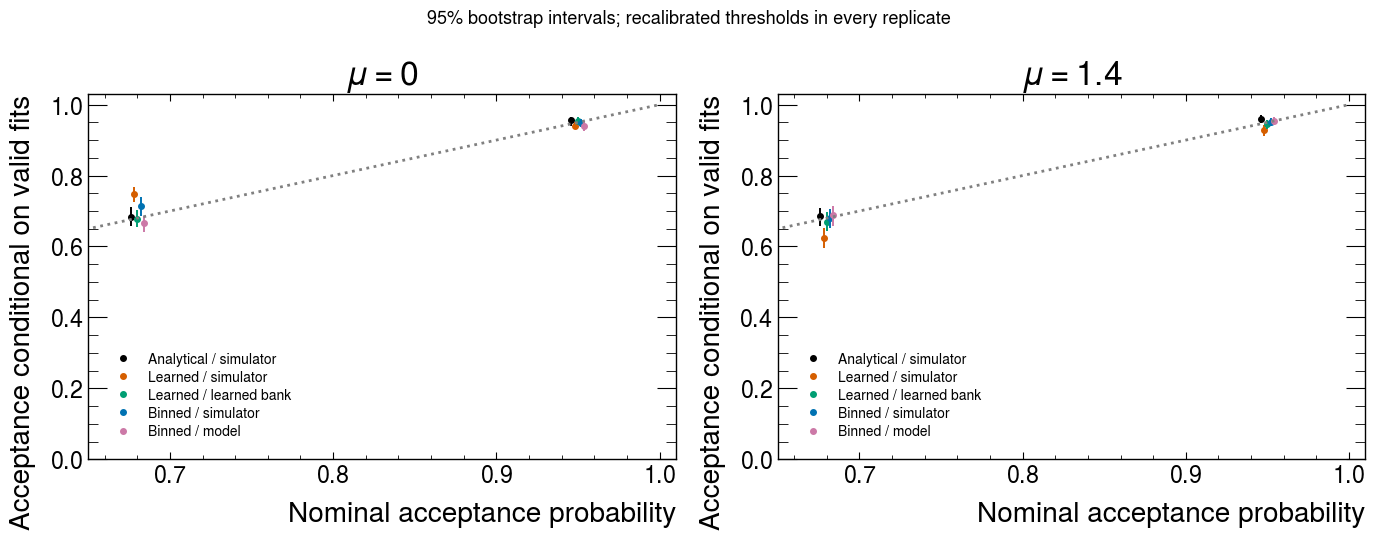

bootstrap_transfer_difference


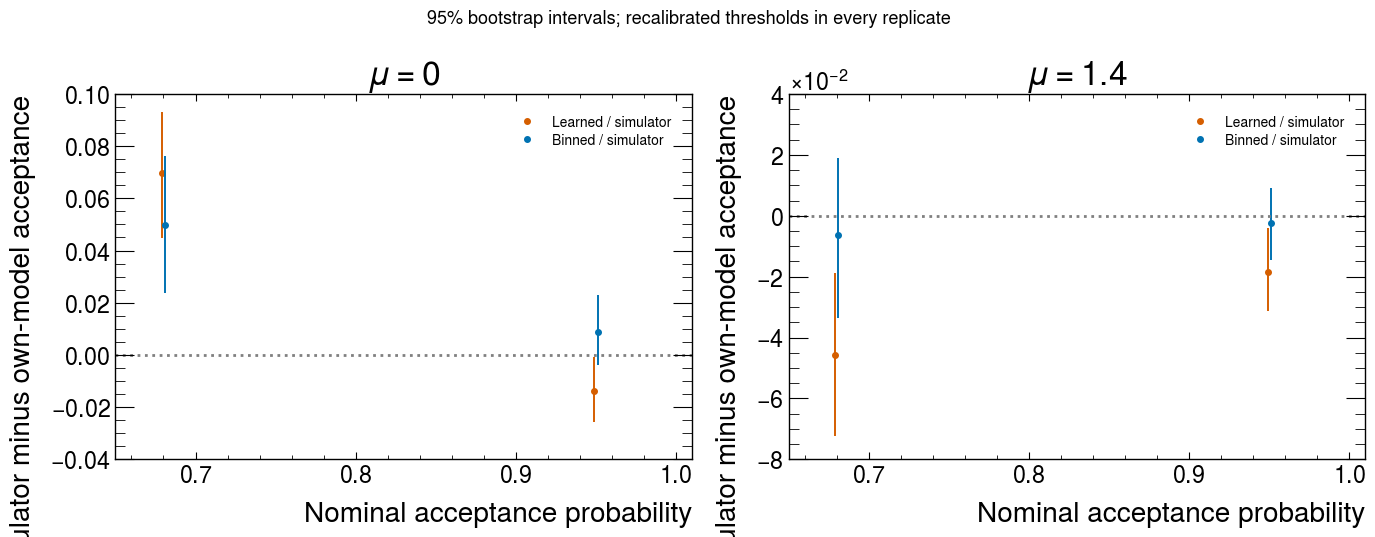

In [7]:
coverage = bootstrap_coverage(
    source, n_bootstrap=N_BOOTSTRAP, seed=BOOTSTRAP_SEED,
    levels=COVERAGE_LEVELS,
)
coverage.to_csv(DIAGNOSTIC_DIR / "coverage_bootstrap.csv", index=False)
display(coverage)
show_figures(plot_bootstrap_coverage(coverage, output=FIGURE_DIR / "coverage"))

### Load the frozen model only for the remaining stages

The next stages verify the source run before reconstructing any events.
Network parameters, learned-ratio normalization, preselection, physical
rates, and observable settings come from the completed source run.
A diagnostic output tag identifies these comparisons separately.

In [8]:
ctx = None
integration = None
refits = None
if RUN_INTEGRATION or RUN_REFITS:
    from poodemo.toy_diagnostic_context import prepare_toy_diagnostic_context
    ctx = prepare_toy_diagnostic_context(
        run, source_tag=SOURCE_TAG, output_tag=OUTPUT_TAG,
    )
    original_n = int(ctx["original_n_per_source"])
    generated_per_source = (
        original_n if BASE_GENERATED_PER_SOURCE is None
        else int(BASE_GENERATED_PER_SOURCE)
    )
    print("Original generated proposals per source:", original_n)
    print("Diagnostic base proposals per source:", generated_per_source)
else:
    print("Saved-table analysis complete. Enable a later stage to load the frozen models.")

Original generated proposals per source: 250000
Diagnostic base proposals per source: 250000


### 3. Independent bin-yield and integration convergence checks

Generate fresh, independent proposal banks, apply the same frozen
preselection, and integrate the analytical physical intensities in the
**unchanged** observable bins. Compare the resulting bin means and total
rates with notebook 11's original predictions. This directly tests the
assertion that simulator histograms and model Poisson draws should
share the same bin means.

The base sample size counts proposals **before preselection, per
proposal source**. It is read from the original quadrature manifest;
accepted counts differ. Bank sizes and independent seeds are recorded.
Increasing this size changes numerical precision, not physical exposure.
Compare the independent replicas and their MC uncertainties; a single
random realization need not improve monotonically with size. Plot error
bars represent the fresh validation bank uncertainty conditional on the
original frozen model. Fixed-partition uncertainty estimates for the
original bank are also tabulated, but its observable normalizers depend
on that bank: a naive old-plus-new quadrature error is not an exact pull.

At the boundary, use \(\kappa=\sqrt\mu\). For fixed bin means
\(\nu_i^{\rm model}(\kappa)\), the expected score is
\[
E_{\rm true}[U_\kappa]
=\sum_i\left(\frac{\nu_i^{\rm true}}{\nu_i^{\rm model}}-1\right)
\frac{\partial\nu_i^{\rm model}}{\partial\kappa},\qquad
I_{\kappa\kappa}
=\sum_i\frac{(\partial_\kappa\nu_i^{\rm model})^2}
{\nu_i^{\rm model}}.
\]
Inspect \(E[U_\kappa]/\sqrt{I_{\kappa\kappa}}\), with its integration
uncertainty. A negative expected score can leave the constrained Asimov
MLE at zero while changing how often fluctuated experiments land on the
boundary. This local score does not predict which distant minimum wins;
the paired branch analysis addresses that separate question. The
validation expectation here is independently estimated,
not an exact infinite-MC truth.

The 36-bin templates below subdivide the original 12 bins into three;
they preserve their boundaries and keep 0.5 inside a bin. They use the
**same power \(a\)**. No spline interpolation is introduced.

bin_closure


,replica,generated_per_source,n_bins,mu_test,bin,left,right,estimate,baseline,delta,validation_se,baseline_se_fixed_partition,combined_se_fixed_partition,relative,ratio,ratio_se,residual_validation_only,residual_combined_fixed_partition
0,0,1250000,12,0.0,0,0.000000,0.041667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
1,0,1250000,12,0.0,1,0.041667,0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
2,0,1250000,12,0.0,2,0.125000,0.208333,5118.432885,5117.608902,0.823983,25.104675,56.117707,61.477164,0.000161,1.000161,0.004906,0.032822,0.013403
3,0,1250000,12,0.0,3,0.208333,0.291667,17259.958849,17216.406383,43.552466,40.059192,89.472051,98.030540,0.002530,1.002530,0.002327,1.087203,0.444274
4,0,1250000,12,0.0,4,0.291667,0.375000,10865.689971,10953.422412,-87.732440,27.248611,61.187805,66.980850,-0.008010,0.991990,0.002488,-3.219703,-1.309814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,1250000,36,1.4,31,0.819444,0.847222,1770.949815,1778.421736,-7.471921,5.458159,12.232098,13.394615,-0.004201,0.995799,0.003069,-1.368945,-0.557830
188,1,1250000,36,1.4,32,0.847222,0.875000,1828.462398,1816.722054,11.740343,5.415646,12.071368,13.230538,0.006462,1.006462,0.002981,2.167857,0.887367
189,1,1250000,36,1.4,33,0.875000,0.916667,2774.637504,2751.217783,23.419721,6.382340,14.216409,15.583342,0.008512,1.008512,0.002320,3.669457,1.502869
190,1,1250000,36,1.4,34,0.916667,0.958333,1135.140985,1128.685407,6.455577,4.052650,9.036361,9.903524,0.005720,1.005720,0.003591,1.592928,0.651846


rate_closure


,replica,generated_per_source,selected,model,mu_test,estimate,standard_error,baseline,baseline_se_fixed_partition,relative,ratio,ratio_se
0,0,1250000,2258396,analytic,0.0,85453.474846,49.070764,85436.696000,109.769647,0.000196,1.000196,0.000574
1,0,1250000,2258396,analytic,1.4,84244.494935,48.542790,84227.180177,108.588283,0.000206,1.000206,0.000576
2,0,1250000,2258396,learned,0.0,85453.494723,49.045910,85436.696000,NaN,0.000197,1.000197,0.000574
3,0,1250000,2258396,learned,1.4,84244.663218,48.512730,84227.180177,NaN,0.000208,1.000208,0.000576
4,1,1250000,2257056,analytic,0.0,85443.595941,49.074535,85436.696000,109.769647,0.000081,1.000081,0.000574
5,1,1250000,2257056,analytic,1.4,84235.043753,48.546910,84227.180177,108.588283,0.000093,1.000093,0.000576
6,1,1250000,2257056,learned,0.0,85443.978715,49.051417,85436.696000,NaN,0.000085,1.000085,0.000574
7,1,1250000,2257056,learned,1.4,84235.861026,48.518697,84227.180177,NaN,0.000103,1.000103,0.000576


convergence


,replica,generated_per_source,selected,model,mu_test,estimate,standard_error,baseline,baseline_se_fixed_partition,relative,ratio,ratio_se
0,0,250000,451528,analytic,0.0,85419.491759,109.793816,85436.696000,109.769647,-0.000201,0.999799,0.001285
1,0,250000,451528,analytic,1.4,84212.618352,108.614773,84227.180177,108.588283,-0.000173,0.999827,0.001290
2,0,250000,451528,learned,0.0,85418.391397,109.732288,85436.696000,NaN,-0.000214,0.999786,0.001284
3,0,250000,451528,learned,1.4,84212.038112,108.543292,84227.180177,NaN,-0.000180,0.999820,0.001289
4,0,500000,902870,analytic,0.0,85363.014676,77.534861,85436.696000,109.769647,-0.000862,0.999138,0.000908
5,0,500000,902870,analytic,1.4,84155.276554,76.701101,84227.180177,108.588283,-0.000854,0.999146,0.000911
6,0,500000,902870,learned,0.0,85362.416555,77.494345,85436.696000,NaN,-0.000869,0.999131,0.000907
7,0,500000,902870,learned,1.4,84155.556945,76.652910,84227.180177,NaN,-0.000850,0.999150,0.000910
8,0,1250000,2258396,analytic,0.0,85453.474846,49.070764,85436.696000,109.769647,0.000196,1.000196,0.000574
9,0,1250000,2258396,analytic,1.4,84244.494935,48.542790,84227.180177,108.588283,0.000206,1.000206,0.000576


score_closure


,replica,generated_per_source,n_bins,mu_test,expected_score,standard_error,model_fisher,standardized_score,standardized_se,unsupported_expected_yield,negative_learned_nodes
0,0,250000,12,0.0,-1.011285,4.820054,661.968563,-0.039306,0.187341,0.0,0
1,0,250000,12,1.4,13.865906,3.511658,468.025140,0.640935,0.162322,0.0,0
2,0,250000,36,0.0,-2.526066,4.789639,663.656915,-0.098056,0.185922,0.0,0
3,0,250000,36,1.4,12.657272,3.487490,471.051308,0.583185,0.160686,0.0,0
4,0,500000,12,0.0,-2.457099,3.409839,661.968563,-0.095500,0.132530,0.0,0
5,0,500000,12,1.4,10.610099,2.481439,468.025140,0.490439,0.114701,0.0,0
6,0,500000,36,0.0,-3.741508,3.388625,663.656915,-0.145236,0.131538,0.0,0
7,0,500000,36,1.4,10.328741,2.464736,471.051308,0.475897,0.113563,0.0,0
8,0,1250000,12,0.0,-5.875760,2.158293,661.968563,-0.228373,0.083886,0.0,0
9,0,1250000,12,1.4,11.665625,1.569593,468.025140,0.539229,0.072553,0.0,0


bins_12_mu_0


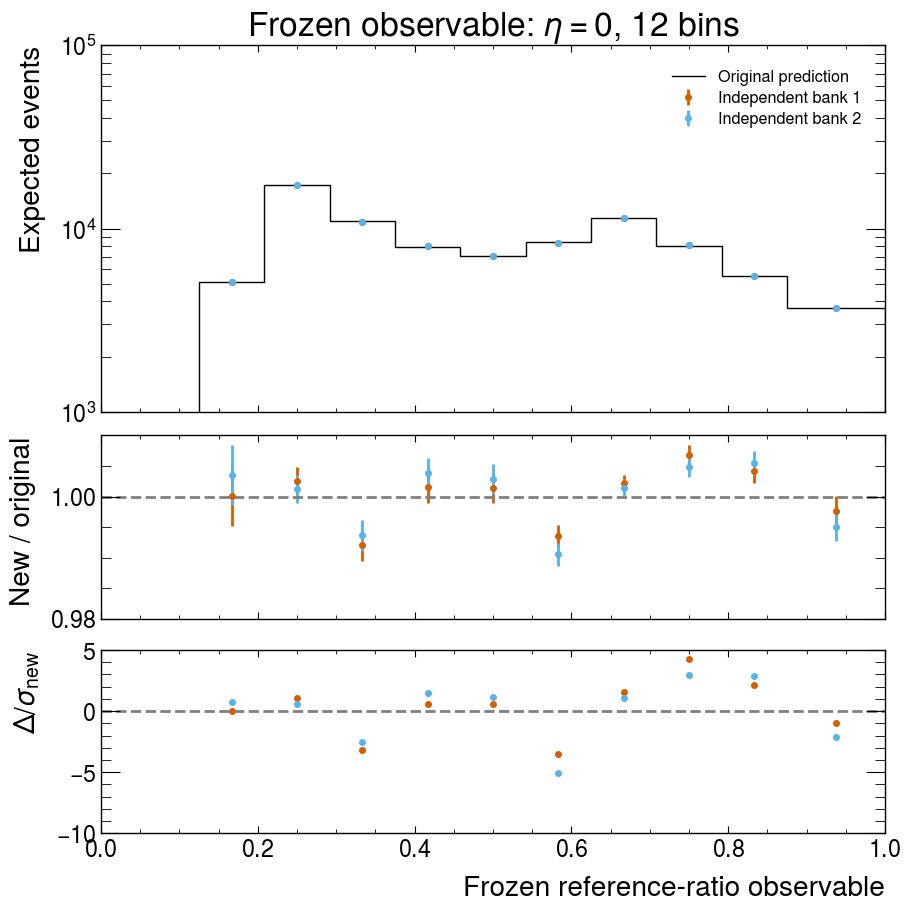

bins_12_mu_1.4


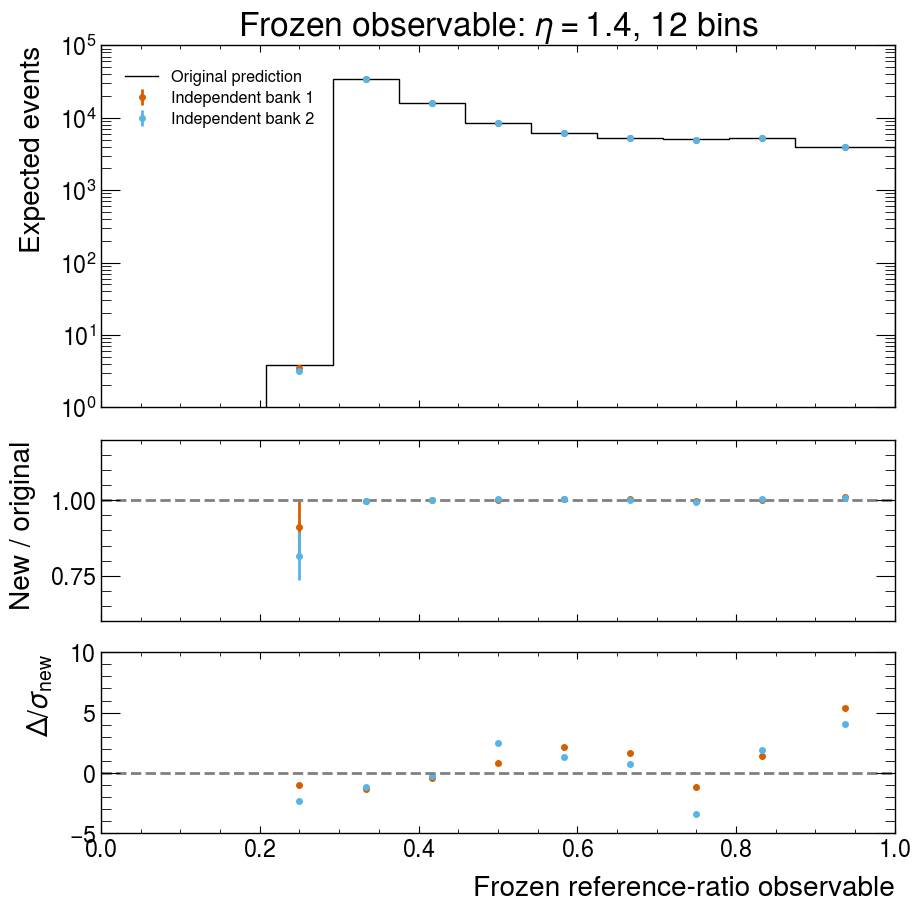

bins_36_mu_0


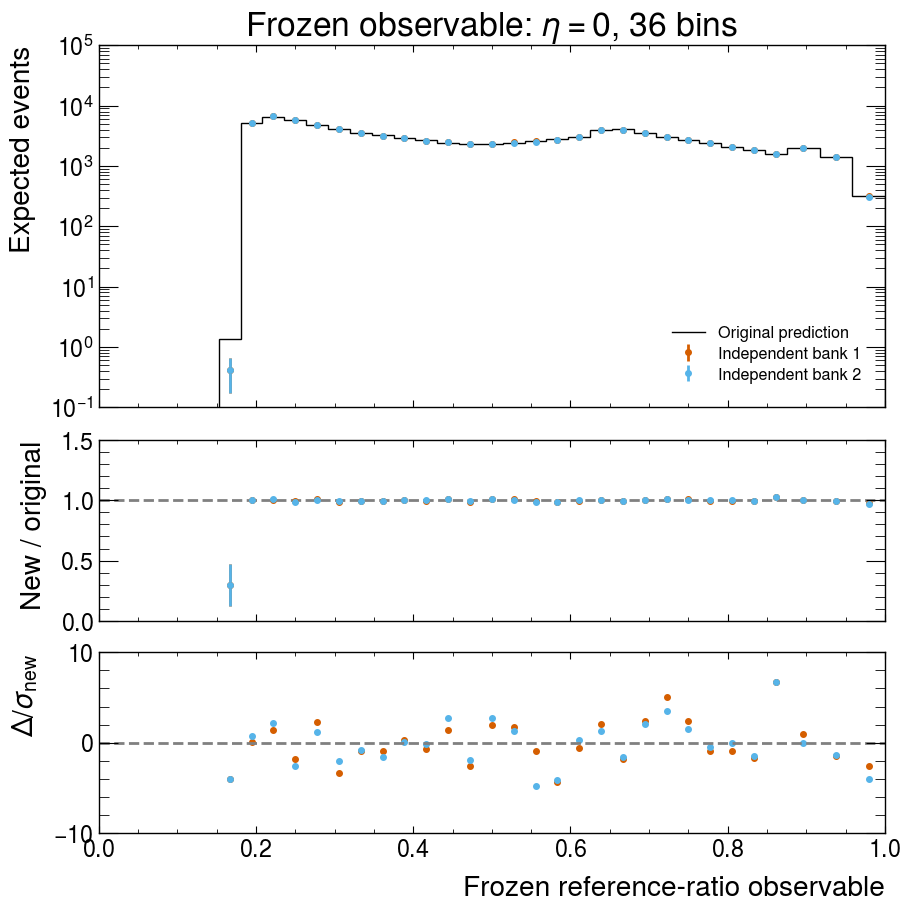

bins_36_mu_1.4


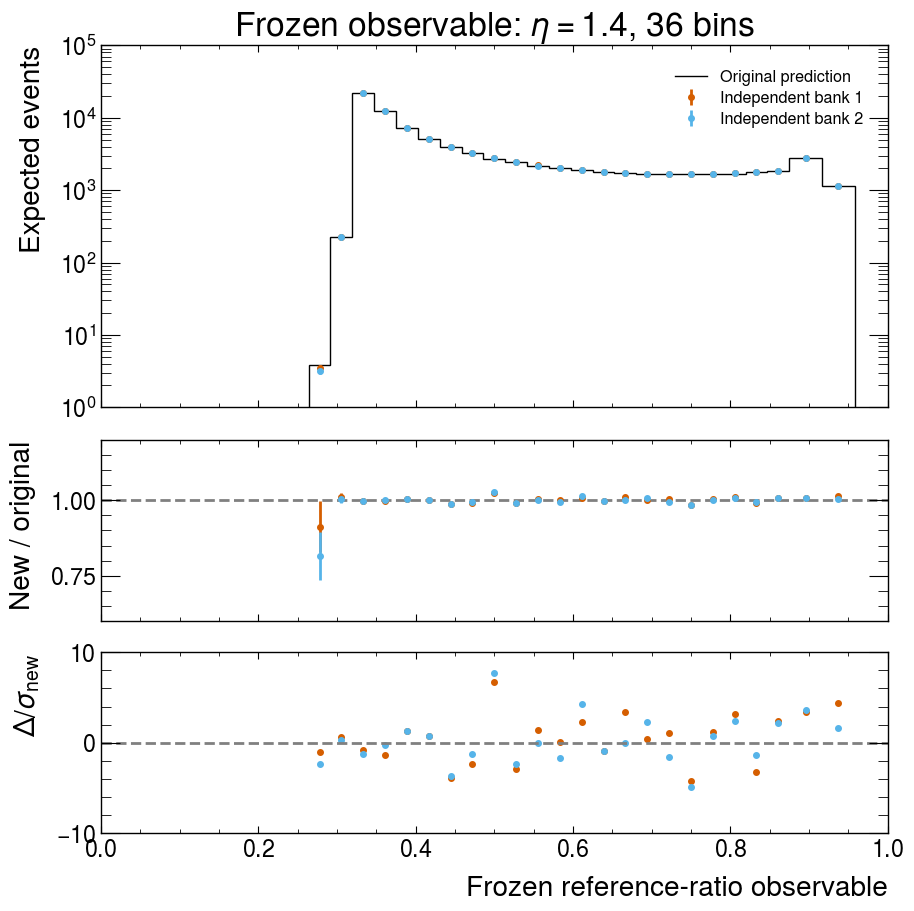

rate_convergence


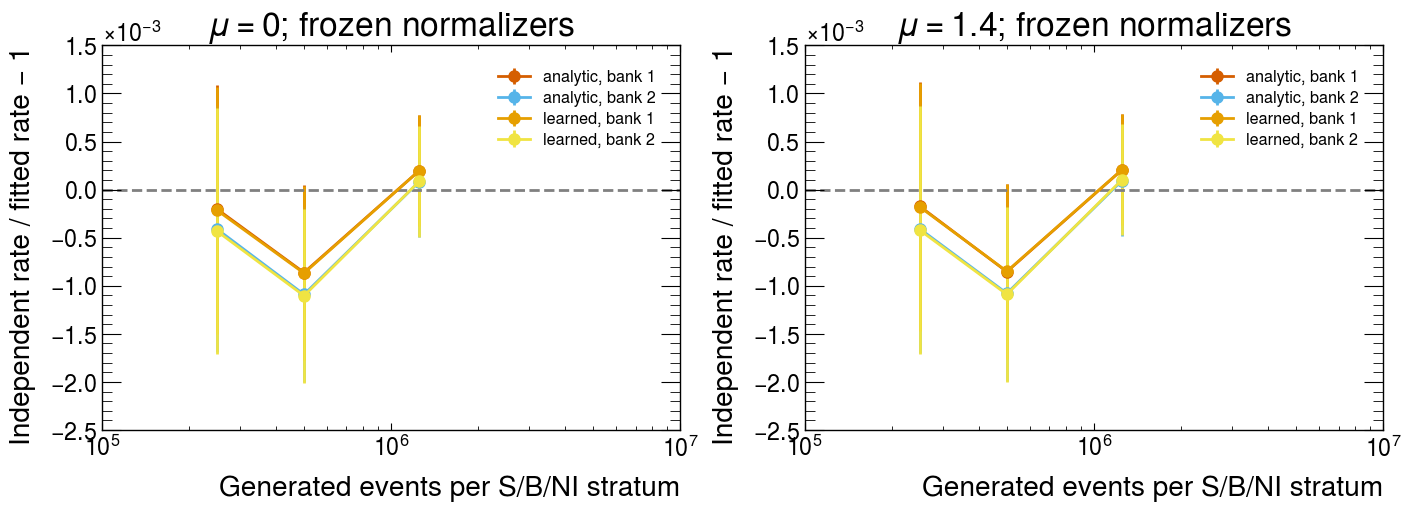

expected_kappa_score


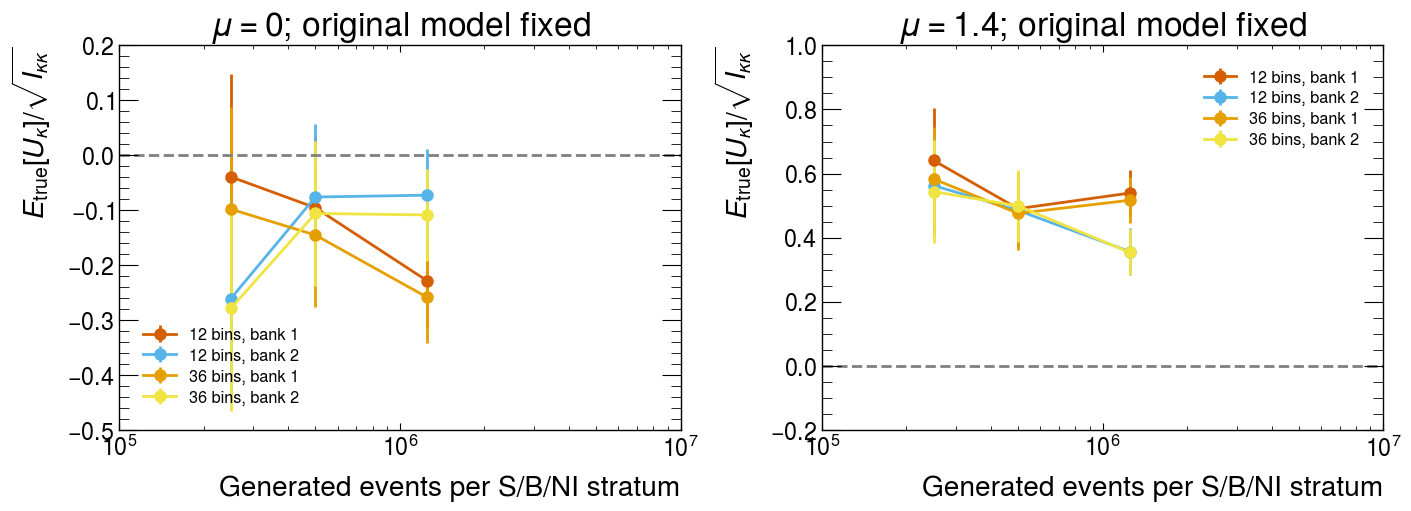

In [9]:
if RUN_INTEGRATION:
    from poodemo.toy_integration_diagnostics import (
        run_integration_diagnostics, plot_integration_diagnostics,
    )
    integration = run_integration_diagnostics(
        ctx, generated_per_source=generated_per_source,
        multiples=BANK_MULTIPLES, replicas=BANK_REPLICAS,
        seed=INTEGRATION_SEED, n_bins=BIN_COUNTS,
        chunk_size=GENERATION_CHUNK_SIZE,
    )
    for name in ("bin_closure", "rate_closure", "convergence", "score_closure"):
        print(name)
        display(integration[name])
    show_figures(plot_integration_diagnostics(
        integration, output=FIGURE_DIR / "integration",
    ))
else:
    print("Independent integration study skipped by RUN_INTEGRATION=False.")

### 4. Reconstruct a random sample and the flagged experiments

The original seed, tested hypothesis, toy ID, and simulator stream
reconstruct the same experiments used in notebook 11. First check the
original fit settings; then compare a denser minimization on the same
range and a fit extended to \(0\leq\mu\leq3\). The notebook checks
reproduced counts, \(q\), and \(\hat\mu\) before showing the diagnostic
summary; a mismatch for an originally valid fit stops interpretation.

The random subset supports comparisons representative of the saved
ensemble. The additional upper-bound toys are intentionally enriched
for difficult cases. Representative likelihood scans prioritize branch
disagreements among the selected experiments. **Do not interpret the
pooled selected-sample fraction as the population probability.**

In [10]:
if RUN_REFITS:
    from poodemo.toy_refit_diagnostics import (
        select_refit_toys, run_refit_diagnostics, plot_refit_diagnostics,
    )
    selection = select_refit_toys(
        source, n_random=N_RANDOM_TOYS, max_flagged=MAX_FLAGGED_TOYS,
        seed=REFIT_SELECTION_SEED, branch_split=BRANCH_SPLIT,
    )
    selection.to_csv(DIAGNOSTIC_DIR / "refit_selection.csv", index=False)
    print("Selected experiments (each is reconstructed with its original RNG stream):")
    display(selection)
    print("Use random-subset summaries for population comparisons; flagged toys are enriched.")
else:
    print("Event reconstruction and likelihood refits skipped by RUN_REFITS=False.")

Selected experiments (each is reconstructed with its original RNG stream):


,mu_test,toy_id,is_random,is_flagged,branch_disagreement,selection_reason,original_delta_q,branch_split,n_population,n_flagged_population,n_flagged_selected
0,0.0,13,True,False,False,random,0.206302,1.0,5000,164,164
1,0.0,28,True,False,True,random,1.513394,1.0,5000,164,164
2,0.0,45,False,True,True,upper boundary,2.913819,1.0,5000,164,164
3,0.0,50,False,True,True,upper boundary,0.728167,1.0,5000,164,164
4,0.0,52,True,False,False,random,0.000000,1.0,5000,164,164
...,...,...,...,...,...,...,...,...,...,...,...
552,1.4,4914,True,False,False,random,-0.463070,1.0,5000,0,0
553,1.4,4928,True,False,False,random,0.170159,1.0,5000,0,0
554,1.4,4943,True,False,False,random,0.351259,1.0,5000,0,0
555,1.4,4955,True,False,False,random,0.083082,1.0,5000,0,0


Use random-subset summaries for population comparisons; flagged toys are enriched.


### 5. Separate optimizer, fit-range, integration, and binning effects

Compare one controlled change at a time. Dense fits at the original
upper bound check numerical minimization; extending only the bound
checks truncation. With the same range and minimizer, compare the
original 12 bins against their nested 36-bin refinement, using common
integration information. When the independent integration stage was
run, the refits also compare original and independently estimated
template/rate predictions while keeping the observable fixed.

Likelihood scans for representative selected experiments expose both
local minima and the tested value. Inspect failed fits and repeated
upper-bound hits before drawing conclusions about tails. Reaching 3
would mean the wider range still needs investigation; 3 is a diagnostic
choice, not a proof that the global minimum has been found.

More bins need not move every individual \(q_\mu\) monotonically toward
the unbinned value: both the numerator and fitted denominator change.
Use paired differences, branch changes, and the random-subset summaries
together. We keep \(a\) fixed so a separate future transformation study
does not become confounded with this bin-count comparison.

Reproduction of notebook 11 under its original settings:


,mu_test,toy_id,is_random,is_flagged,branch_disagreement,selection_reason,original_delta_q,branch_split,n_population,n_flagged_population,...,wide_valid,delta_q_wide,analytic_wide_q,analytic_wide_mu_hat,delta_q_analytic_wide,analytic_integrated_q,analytic_integrated_mu_hat,delta_q_analytic_integrated,matched_analytic_q,delta_q_matched_analytic
2,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,1.420045e-14,0.022992,0.000032,1.420045e-14,0.281505,0.000403,-0.258513,0.022992,1.420045e-14
8,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,0.000000e+00,0.022992,0.000032,2.063018e-01,0.281505,0.000403,-0.052211,0.022992,2.063018e-01
11,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,1.430106e-14,0.022992,0.000032,5.630626e-03,0.281505,0.000403,-0.252882,0.022992,5.630626e-03
15,0.0,28,True,False,True,random,1.513394,1.0,5000,164,...,True,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
21,0.0,28,True,False,True,random,1.513394,1.0,5000,164,...,True,1.778577e-13,0.000000,0.000000,1.513394e+00,0.000000,0.000000,1.513394,0.000000,1.513394e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7223,1.4,4955,True,False,False,random,0.083082,1.0,5000,0,...,True,0.000000e+00,0.089620,1.432353,8.308178e-02,0.043992,1.377051,0.128710,0.089620,8.308178e-02
7226,1.4,4955,True,False,False,random,0.083082,1.0,5000,0,...,True,4.260481e-14,0.089620,1.432353,-2.063962e-02,0.043992,1.377051,0.024989,0.089620,-2.063962e-02
7230,1.4,4990,True,False,False,random,0.003972,1.0,5000,0,...,True,1.780000e-14,0.002320,1.394750,1.780000e-14,0.311991,1.338312,-0.309671,0.002320,1.780000e-14
7236,1.4,4990,True,False,False,random,0.003972,1.0,5000,0,...,True,-7.100223e-15,0.002320,1.394750,3.972366e-03,0.311991,1.338312,-0.305699,0.002320,3.972366e-03


Original valid-source fits reproduced. Refit summary:


,mu_test,case,variant,n_random,n_valid,n_failed,mean_q,mean_delta_q_saved,mean_delta_q_analytic_wide,mean_delta_q_matched_analytic,upper_boundary_fraction,upper_boundary_se,upper_boundary_mu,high_branch_fraction,zero_q_fraction,summary_population
0,0.0,analytic_simulator,analytic_integrated,200,200,0,0.570606,1.472005e-01,1.472005e-01,0.000000e+00,0.000,0.000000,3.0,0.010,0.455,random controls only
1,0.0,analytic_simulator,dense,200,200,0,0.423405,1.154320e-14,1.274119e-14,1.274119e-14,0.000,0.000000,2.0,0.045,0.565,random controls only
2,0.0,analytic_simulator,original,200,200,0,0.423405,0.000000e+00,1.197989e-15,1.197989e-15,0.000,0.000000,2.0,0.045,0.565,random controls only
3,0.0,analytic_simulator,wide,200,200,0,0.423405,-1.197989e-15,0.000000e+00,0.000000e+00,0.000,0.000000,3.0,0.045,0.565,random controls only
4,0.0,binned_simulator,bins36,200,200,0,0.817077,4.688108e-02,3.936711e-01,3.936711e-01,0.000,0.000000,3.0,0.190,0.460,random controls only
5,0.0,binned_simulator,dense,200,200,0,0.770196,-1.562479e-14,3.467900e-01,3.467900e-01,0.035,0.012995,2.0,0.200,0.445,random controls only
6,0.0,binned_simulator,integrated12,200,200,0,0.684809,-8.538658e-02,2.614034e-01,1.142030e-01,0.000,0.000000,3.0,0.105,0.430,random controls only
7,0.0,binned_simulator,integrated36,200,200,0,0.682389,-8.780663e-02,2.589834e-01,1.117829e-01,0.000,0.000000,3.0,0.095,0.445,random controls only
8,0.0,binned_simulator,original,200,200,0,0.770196,0.000000e+00,3.467900e-01,3.467900e-01,0.035,0.012995,2.0,0.200,0.445,random controls only
9,0.0,binned_simulator,wide,200,200,0,0.788177,1.798166e-02,3.647717e-01,3.647717e-01,0.000,0.000000,3.0,0.200,0.445,random controls only


Paired comparisons (first 30 rows):


,mu_test,toy_id,is_random,is_flagged,branch_disagreement,selection_reason,original_delta_q,branch_split,n_population,n_flagged_population,...,wide_valid,delta_q_wide,analytic_wide_q,analytic_wide_mu_hat,delta_q_analytic_wide,analytic_integrated_q,analytic_integrated_mu_hat,delta_q_analytic_integrated,matched_analytic_q,delta_q_matched_analytic
0,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,2.585127e-01,0.022992,0.000032,2.585127e-01,0.281505,0.000403,0.000000,0.281505,0.000000e+00
1,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,1.420045e-14,0.022992,0.000032,1.420045e-14,0.281505,0.000403,-0.258513,0.022992,1.420045e-14
2,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,1.420045e-14,0.022992,0.000032,1.420045e-14,0.281505,0.000403,-0.258513,0.022992,1.420045e-14
3,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,0.000000e+00,0.022992,0.000032,0.000000e+00,0.281505,0.000403,-0.258513,0.022992,0.000000e+00
4,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,-7.108816e-02,0.022992,0.000032,1.352137e-01,0.281505,0.000403,-0.123299,0.022992,1.352137e-01
5,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,0.000000e+00,0.022992,0.000032,2.063018e-01,0.281505,0.000403,-0.052211,0.022992,2.063018e-01
6,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,2.702844e-01,0.022992,0.000032,4.765862e-01,0.281505,0.000403,0.218074,0.281505,2.180735e-01
7,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,2.009773e-01,0.022992,0.000032,4.072792e-01,0.281505,0.000403,0.148766,0.281505,1.487665e-01
8,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,0.000000e+00,0.022992,0.000032,2.063018e-01,0.281505,0.000403,-0.052211,0.022992,2.063018e-01
9,0.0,13,True,False,False,random,0.206302,1.0,5000,164,...,True,0.000000e+00,0.022992,0.000032,2.063018e-01,0.281505,0.000403,-0.052211,0.022992,2.063018e-01


fit_stability


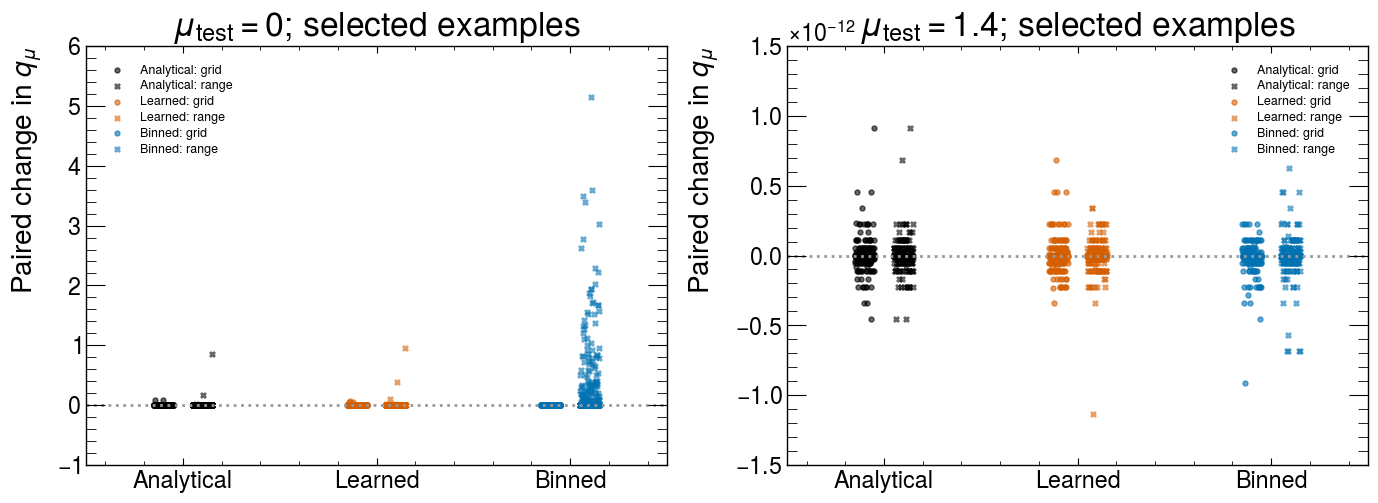

binning_integration


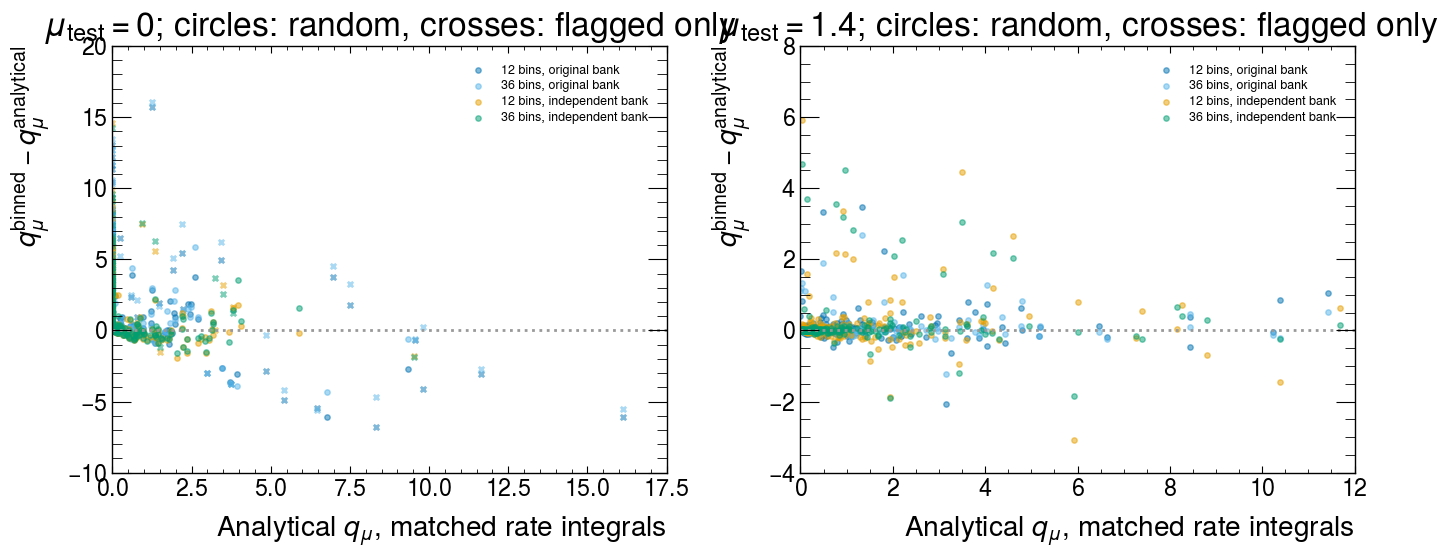

representative_scans


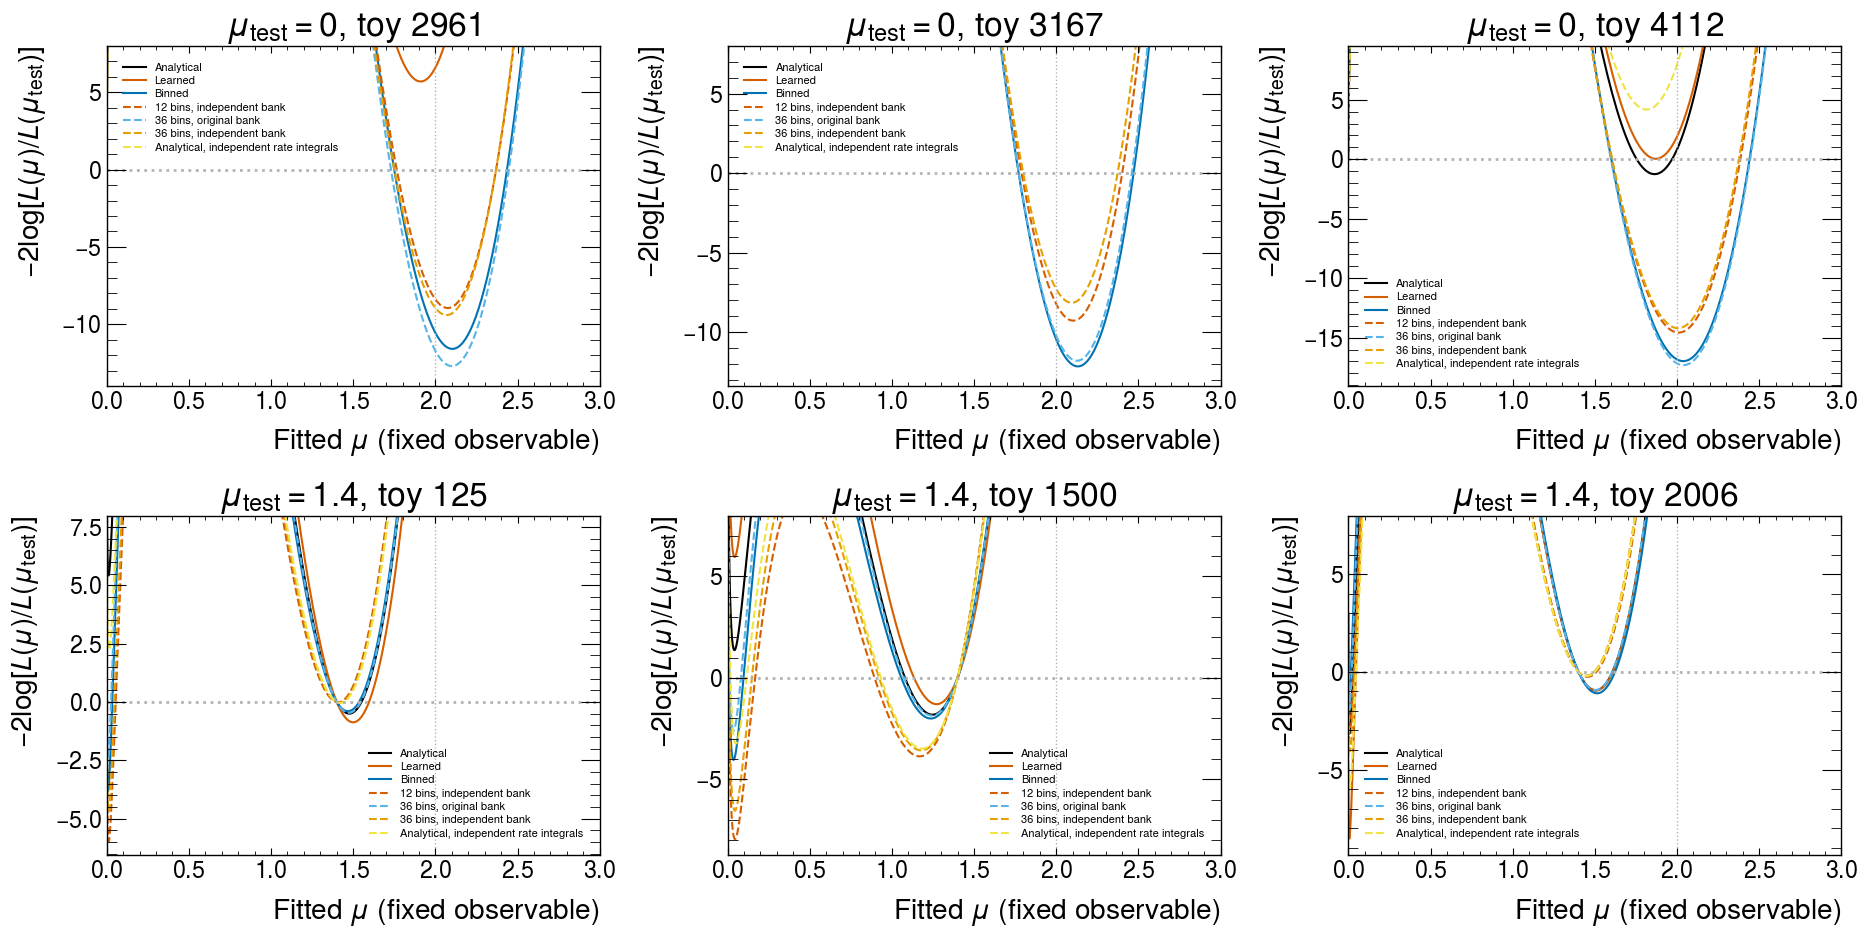

random_boundary_fractions


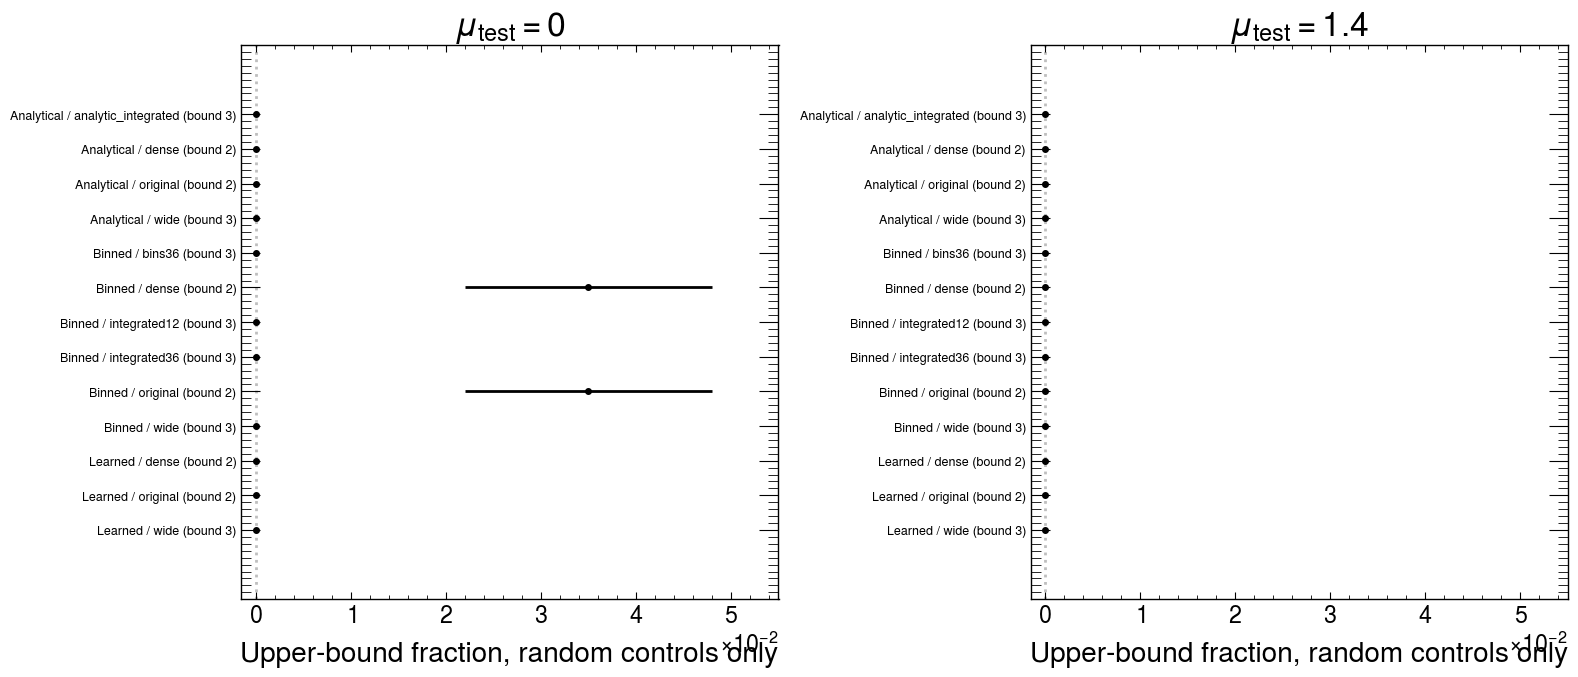

In [11]:
if RUN_REFITS:
    refits = run_refit_diagnostics(
        ctx, selection, integration=integration,
        mu_bounds=WIDE_MU_BOUNDS, grid_size=DENSE_FIT_GRID_SIZE,
        bin_counts=BIN_COUNTS, n_scans=N_LIKELIHOOD_SCANS,
        progress_every=PROGRESS_EVERY,
    )
    original_checks = refits["comparisons"].loc[
        refits["comparisons"].variant.eq("original")
    ]
    print("Reproduction of notebook 11 under its original settings:")
    display(original_checks)
    mismatches = original_checks.loc[
        original_checks.saved_valid.astype(bool)
        & ~original_checks.reproduction_pass.astype(bool)
    ]
    if len(mismatches):
        display(mismatches)
        raise RuntimeError(
            "Original-settings fits did not reproduce saved valid notebook 11 results. "
            "Inspect these records before interpreting numerical or statistical differences."
        )
    print("Original valid-source fits reproduced. Refit summary:")
    display(refits["summary"])
    print("Paired comparisons (first 30 rows):")
    display(refits["comparisons"].head(30))
    show_figures(plot_refit_diagnostics(refits, output=FIGURE_DIR / "refits"))

### Reading the result

- **Different winning minima dominate the paired discrepancy:** the
  compression changes discrimination between interference solutions.
- **Dense fits change results at the same bound:** improve minimization
  before interpreting the ensemble statistically.
- **The wider range changes boundary toys:** the original scan domain
  truncated relevant alternatives.
- **Independent bin means or expected scores disagree with the original
  templates:** investigate integration precision before attributing all
  nonclosure to neural ratios or compression.
- **The 36-bin refinement reduces branch disagreements after those
  checks:** this supports finite-bin information loss as a contributor.

None of these diagnostics changes the learned-model toy interpretation
from notebook 11: those toys and their likelihood share a finite bank.
An independent learned-model sampling test remains a separate question.
This notebook adds no nuisance parameters and does not propagate finite
template statistics as a profiled uncertainty.

In [12]:
print("Notebook 11 source records were preserved.")
print("Diagnostic tables and checkpoints:", DIAGNOSTIC_DIR)
print("Figures:", FIGURE_DIR)

Notebook 11 source records were preserved.
Diagnostic tables and checkpoints: /content/drive/MyDrive/poodemo/runs/paper-distinct-s-v4/results/12_toy_diagnostics/toy_diagnostics
Figures: /content/drive/MyDrive/poodemo/runs/paper-distinct-s-v4/plots/12_toy_diagnostics/toy_diagnostics


### 6. Follow-up: repeat the paired fits across independent, larger banks

**Start here for the new tests.** In a fresh runtime, execute the first
two code cells of this notebook: runtime setup, then common imports and
`create_run`. Keep the same v4 run name, mode, and configuration. Then
jump directly to this section. The completed stages above do not need
to run again, and their saved results remain available for comparison.

We now refit the **exact same selected simulator experiments** with
both independent integration replicas, at every saved bank size and
at a new, larger size. The default extends each 1x/2x/5x bank to 10x.
The analytical benchmark receives rate integrals from the same bank
used for the corresponding binned predictions. Its event densities
remain analytical; its selected-rate integrals are numerical.

This addresses two questions separately: whether the result changes
when replacing replica 0 by replica 1, and whether those changes shrink
as each bank grows. We compare mean \(q_\mu\), the paired
binned-minus-analytical difference, the zero-\(q\) fraction, and branch
disagreement. The 12-bin model and its nested 36-bin refinement use the
same events, fit bounds, minimizer, and integration proposals.

The observable, original normalization constants, networks, physical
exposure, and preselection stay frozen. These templates use the
**analytical ratio observable**, as in the completed refit stage; the
bank extension evaluates the frozen selector and analytical densities,
without retraining networks or evaluating new learned density ratios.

**Keep `OUTPUT_TAG` unchanged:** it locates the completed integration
checkpoints and saved toy selection. New outputs live under
`convergence/CONVERGENCE_TAG`. Matching checkpoints resume; if changing
the new settings, use a new `CONVERGENCE_TAG` (for example, to request
`EXTRA_BANK_MULTIPLES=(10, 20)`). The original stages are preserved.

In [13]:
# This follow-up is independent of the earlier analysis-stage variables.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
from IPython.display import display

from poodemo.toy_diagnostic_context import prepare_toy_diagnostic_context
from poodemo.toy_convergence_banks import prepare_convergence_banks
from poodemo.toy_convergence_refits import (
    load_convergence_selection, run_convergence_refits, plot_convergence_refits,
)

hep.style.use("ATLAS")  # Typography and ticks; no experiment label.
plt.rcParams.update({"axes.grid": False, "figure.dpi": 110})

SOURCE_TAG = "toy_study_direct"
OUTPUT_TAG = "toy_diagnostics"  # Must match the completed stages above.
CONVERGENCE_TAG = "bank_convergence"  # New checkpoints live below this tag.
EXTRA_BANK_MULTIPLES = (10,)  # Extend the saved 1x/2x/5x banks, for both replicas.
CONVERGENCE_BIN_COUNTS = (12, 36)
CONVERGENCE_MU_BOUNDS = (0.0, 3.0)
CONVERGENCE_GRID_SIZE = 129
CONVERGENCE_PROGRESS_EVERY = 10

convergence_context = prepare_toy_diagnostic_context(
    run, source_tag=SOURCE_TAG, output_tag=OUTPUT_TAG,
)
convergence_selection = load_convergence_selection(convergence_context)
convergence_figure_dir = (
    Path(ROOT) / "plots" / "12_toy_diagnostics" / OUTPUT_TAG
    / "convergence" / CONVERGENCE_TAG
)
convergence_figure_dir.mkdir(parents=True, exist_ok=True)


def show_convergence_figures(figures):
    for name, figure in figures.items():
        print(name)
        display(figure)
        plt.close(figure)


print("Verified saved toy selection; no new random subset was drawn:")
display(convergence_selection.groupby("mu_test").agg(
    selected=("toy_id", "size"),
    random=("is_random", "sum"),
    flagged=("is_flagged", "sum"),
))
print("New bank multiples:", EXTRA_BANK_MULTIPLES)
print("Population summaries use only the saved random subset.")
print("New diagnostic tag:", CONVERGENCE_TAG)

Verified saved toy selection; no new random subset was drawn:


,selected,random,flagged
mu_test,,,
0.0,357,200,164
1.4,200,200,0


New bank multiples: (10,)
Population summaries use only the saved random subset.
New diagnostic tag: bank_convergence


#### Recover both replicas and extend their integration prefixes

The saved 1x/2x/5x component sums are reused. Only the additional proposals
needed for the larger banks are generated and preselected. Sample sizes
count generated events **per proposal source before preselection**;
multiplying the bank size does not multiply the experiment's luminosity.

Within a replica, larger banks contain the smaller prefixes and are
therefore correlated. Replica 0 and replica 1 have independent proposal
streams. The helper verifies the saved configuration and retains this
distinction in its provenance. This stage can take time; intermediate
checkpoints allow it to resume after interruption.

In [14]:
convergence_banks = prepare_convergence_banks(
    convergence_context,
    extra_multiples=EXTRA_BANK_MULTIPLES,
    bin_counts=CONVERGENCE_BIN_COUNTS,
    convergence_tag=CONVERGENCE_TAG,
)
print("Integration provenance:")
display(pd.Series(convergence_banks["metadata"]))
print("Independent bank checkpoints available for refitting:")
display(pd.DataFrame([
    {"replica": replica, "generated_per_source": size}
    for replica, size in sorted(convergence_banks["banks"])
]))

Convergence bank 1/2, S: 2,500,000 generated, 2,285,705 selected
Convergence bank 1/2, B: 2,500,000 generated, 2,002,399 selected
Convergence bank 1/2, NI: 2,500,000 generated, 227,718 selected
Convergence bank 2/2, S: 2,500,000 generated, 2,284,861 selected
Convergence bank 2/2, B: 2,500,000 generated, 2,003,425 selected
Convergence bank 2/2, NI: 2,500,000 generated, 226,447 selected
Integration provenance:


,0
version,1
convergence_tag,bank_convergence
source_fingerprint,a5fb642ec9bae574a70d413574d05373d7b6c2af1a3c88...
original_integration_fingerprint,55144179b695e21c3889a8c778be8d8f8848ee3b482a50...
original_files_sha256,{'configuration.json': 'c2ea21cfa8622aa375ce12...
original_sizes,"[250000, 500000, 1250000]"
sizes,"[250000, 500000, 1250000, 2500000]"
replicas,2
generated_per_source,250000
seed,120524


Independent bank checkpoints available for refitting:


,replica,generated_per_source
0,0,250000
1,0,500000
2,0,1250000
3,0,2500000
4,1,250000
5,1,500000
6,1,1250000
7,1,2500000


#### Refit the same experiments and measure paired changes

The saved `refit_selection.csv` is checked against the original refit
configuration. No toy IDs are redrawn. Both the random controls and
flagged experiments are retained, with their original membership flags.
Only the **random subset** enters population summaries; the additional
flagged toys remain useful individual diagnostics.

For each bank, compare the binned result with the analytical fit using
**that same bank's selected rates**. The convergence tables then compare
each experiment with itself across sizes and replicas. Their paired
standard errors measure variation across the sampled experiments,
conditional on the banks. They are not errors on the MC integration
itself. Failed fits and upper-bound hits must be inspected alongside
the means; they are not silently counted as successful closure.

Integration convergence refits: 10/557 paired experiments complete
Integration convergence refits: 20/557 paired experiments complete
Integration convergence refits: 30/557 paired experiments complete
Integration convergence refits: 40/557 paired experiments complete
Integration convergence refits: 50/557 paired experiments complete
Integration convergence refits: 60/557 paired experiments complete
Integration convergence refits: 70/557 paired experiments complete
Integration convergence refits: 80/557 paired experiments complete
Integration convergence refits: 90/557 paired experiments complete
Integration convergence refits: 100/557 paired experiments complete
Integration convergence refits: 110/557 paired experiments complete
Integration convergence refits: 120/557 paired experiments complete
Integration convergence refits: 130/557 paired experiments complete
Integration convergence refits: 140/557 paired experiments complete
Integration convergence refits: 150/557 paired experiment

,mu_test,bank_kind,replica,generated_per_source,model,n_random,n_valid,n_failed,upper_boundary_fraction
0,0.0,independent,0,250000,analytic,200,200,0,0.0
1,0.0,independent,0,250000,binned12,200,200,0,0.0
2,0.0,independent,0,250000,binned36,200,120,80,0.0
3,0.0,independent,0,500000,analytic,200,200,0,0.0
4,0.0,independent,0,500000,binned12,200,200,0,0.0
5,0.0,independent,0,500000,binned36,200,200,0,0.0
6,0.0,independent,0,1250000,analytic,200,200,0,0.0
7,0.0,independent,0,1250000,binned12,200,200,0,0.0
8,0.0,independent,0,1250000,binned36,200,200,0,0.0
9,0.0,independent,0,2500000,analytic,200,200,0,0.0


Mean q and its toy-sampling standard error, conditional on each bank:


,mu_test,bank_kind,replica,generated_per_source,model,mean_q,mean_q_se
0,0.0,independent,0,250000,analytic,0.466069,0.058976
1,0.0,independent,0,250000,binned12,0.434859,0.060949
2,0.0,independent,0,250000,binned36,0.462170,0.080959
3,0.0,independent,0,500000,analytic,0.453757,0.058861
4,0.0,independent,0,500000,binned12,0.466796,0.063329
5,0.0,independent,0,500000,binned36,0.479286,0.067292
6,0.0,independent,0,1250000,analytic,0.570606,0.070934
7,0.0,independent,0,1250000,binned12,0.684809,0.083707
8,0.0,independent,0,1250000,binned36,0.682389,0.090820
9,0.0,independent,0,2500000,analytic,0.559768,0.072853


Binned minus matched analytical fit on the same toys and integration bank:


,mu_test,bank_kind,replica,generated_per_source,model,n_paired_valid,n_paired_failed,mean_delta_q,mean_delta_q_se,branch_disagreement_fraction,branch_disagreement_se
1,0.0,independent,0,250000,binned12,200.0,0.0,-0.031209,0.040861,0.060000,0.016793
2,0.0,independent,0,250000,binned36,120.0,80.0,-0.040924,0.043519,0.041667,0.018242
4,0.0,independent,0,500000,binned12,200.0,0.0,0.013040,0.036228,0.055000,0.016121
5,0.0,independent,0,500000,binned36,200.0,0.0,0.025530,0.034277,0.035000,0.012995
7,0.0,independent,0,1250000,binned12,200.0,0.0,0.114203,0.054749,0.105000,0.021677
8,0.0,independent,0,1250000,binned36,200.0,0.0,0.111783,0.057360,0.085000,0.019720
10,0.0,independent,0,2500000,binned12,200.0,0.0,0.200424,0.066711,0.140000,0.024536
11,0.0,independent,0,2500000,binned36,200.0,0.0,0.194720,0.067149,0.125000,0.023385
13,0.0,independent,1,250000,binned12,200.0,0.0,0.054689,0.044042,0.090000,0.020236
14,0.0,independent,1,250000,binned36,120.0,80.0,0.058611,0.064645,0.058333,0.021395


Paired changes in the gap with bank size and between independent replicas:


,mu_test,model,metric,comparison_type,from_replica,to_replica,from_size,to_size,n_random,n_valid,n_failed,mean_change,paired_se,uncertainty
324,0.0,binned12,gap,prefix,0,0,250000,500000,200,200,0,0.044249,0.012384,"paired toy-sampling SE, conditional on both ba..."
325,0.0,binned12,gap,prefix,0,0,500000,1250000,200,200,0,0.101163,0.027113,"paired toy-sampling SE, conditional on both ba..."
326,0.0,binned12,gap,prefix,0,0,1250000,2500000,200,200,0,0.086221,0.020077,"paired toy-sampling SE, conditional on both ba..."
327,0.0,binned12,gap,prefix,1,1,250000,500000,200,200,0,-0.075810,0.020154,"paired toy-sampling SE, conditional on both ba..."
328,0.0,binned12,gap,prefix,1,1,500000,1250000,200,200,0,0.280972,0.055053,"paired toy-sampling SE, conditional on both ba..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,1.4,binned36,gap,original,-1,0,250000,2500000,200,200,0,0.049805,0.021020,"paired toy-sampling SE, conditional on both ba..."
392,1.4,binned36,gap,original,-1,1,250000,250000,200,200,0,0.042881,0.038089,"paired toy-sampling SE, conditional on both ba..."
393,1.4,binned36,gap,original,-1,1,250000,500000,200,200,0,0.006258,0.056823,"paired toy-sampling SE, conditional on both ba..."
394,1.4,binned36,gap,original,-1,1,250000,1250000,200,200,0,0.009582,0.031774,"paired toy-sampling SE, conditional on both ba..."


convergence_mean_q


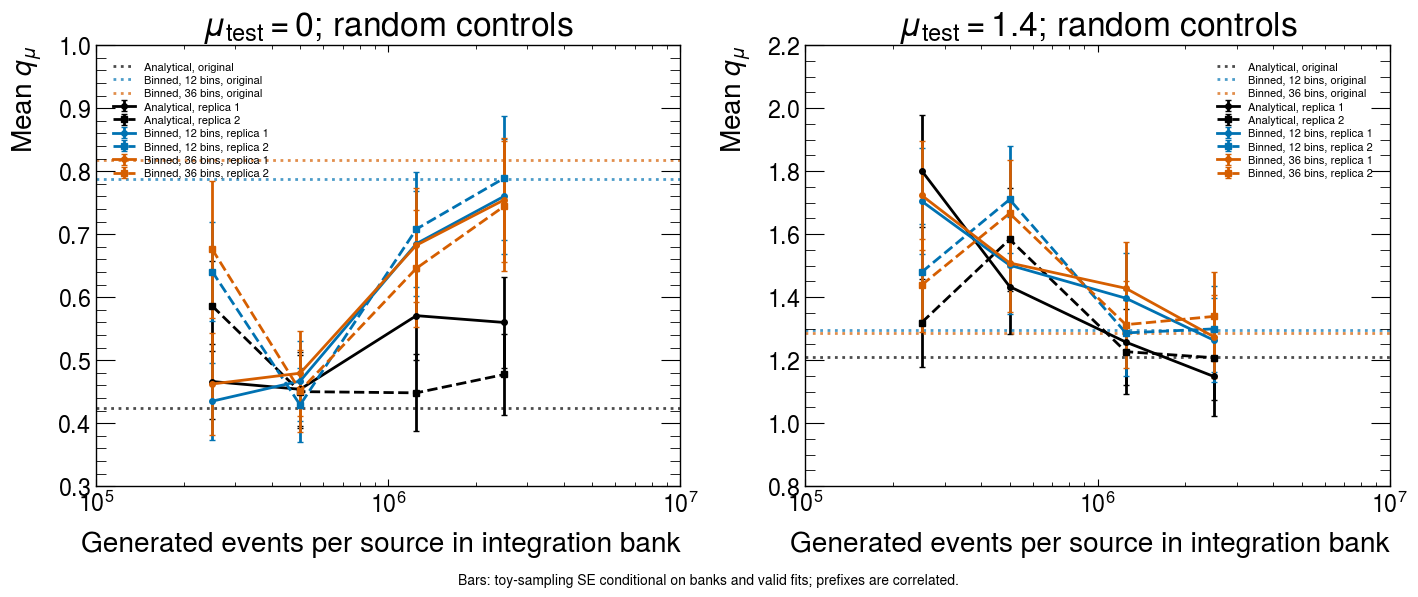

convergence_paired_gap


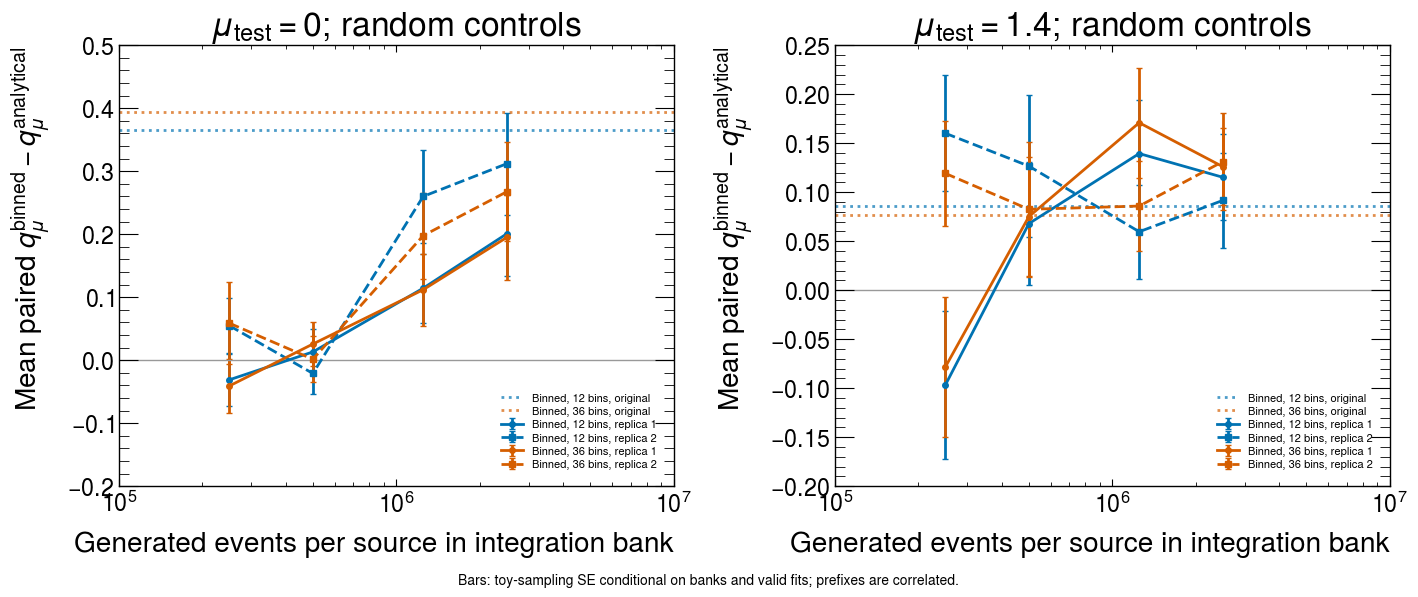

convergence_zero_q


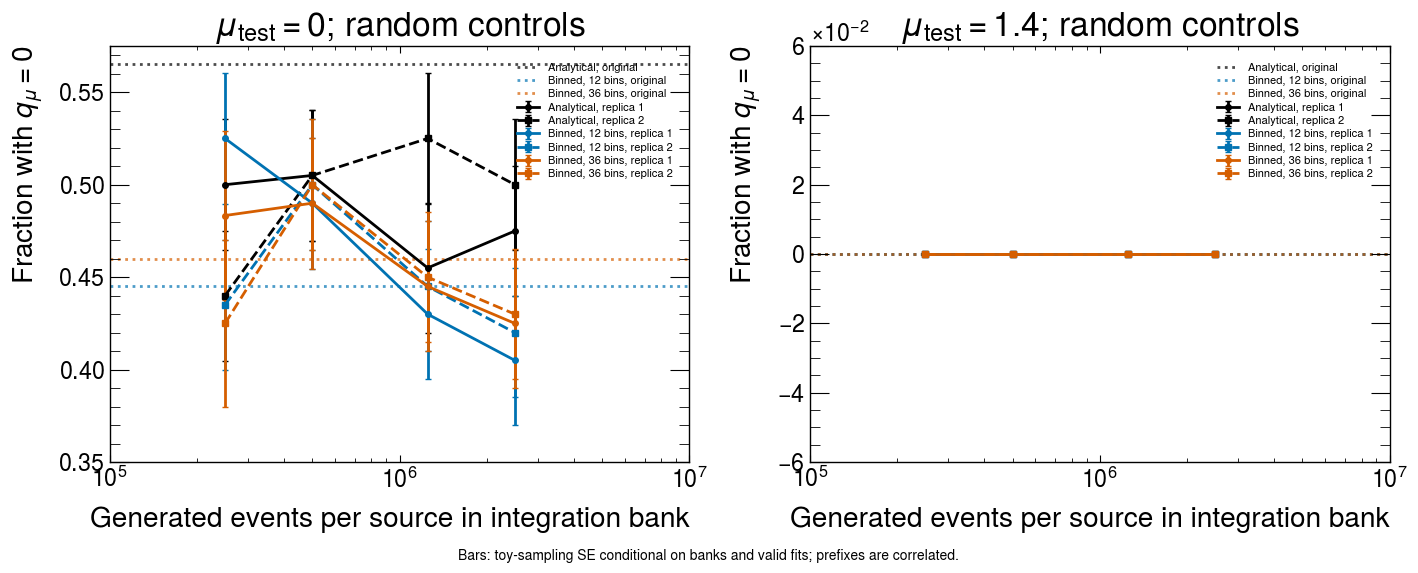

convergence_branches


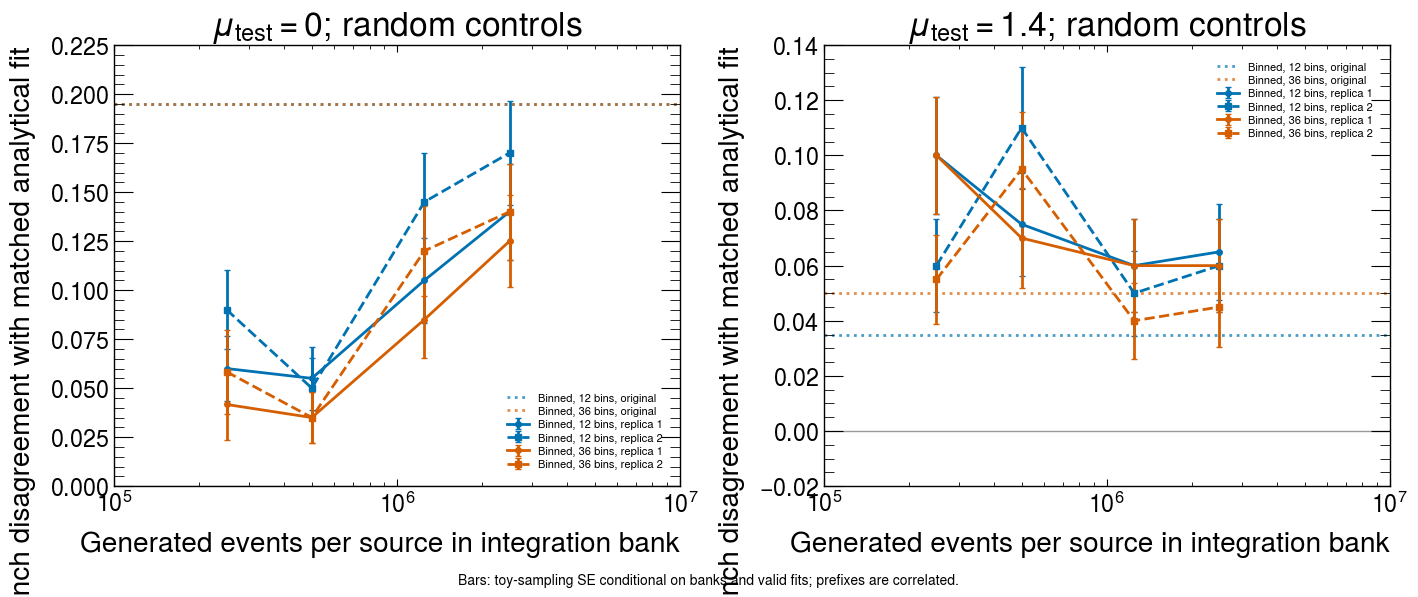

convergence_bank_changes


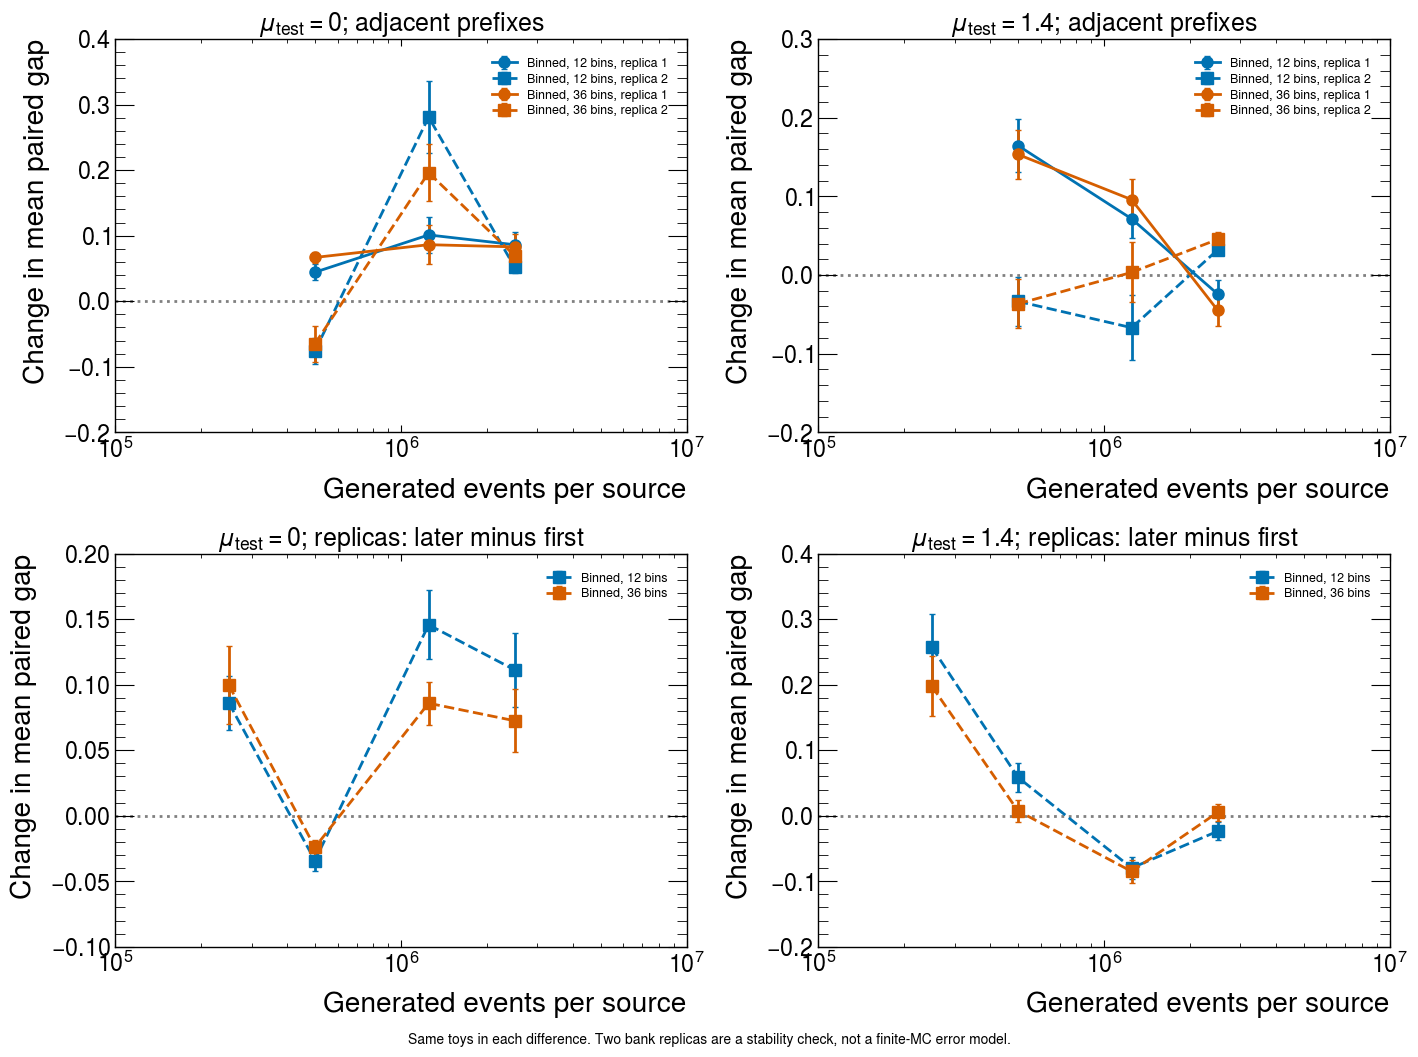

New tables and checkpoints: /content/drive/MyDrive/poodemo/runs/paper-distinct-s-v4/results/12_toy_diagnostics/toy_diagnostics/convergence/bank_convergence/refits
New figures: /content/drive/MyDrive/poodemo/runs/paper-distinct-s-v4/plots/12_toy_diagnostics/toy_diagnostics/convergence/bank_convergence


In [15]:
convergence_study = run_convergence_refits(
    convergence_context, convergence_selection, convergence_banks,
    mu_bounds=CONVERGENCE_MU_BOUNDS,
    grid_size=CONVERGENCE_GRID_SIZE,
    bin_counts=CONVERGENCE_BIN_COUNTS,
    progress_every=CONVERGENCE_PROGRESS_EVERY,
    convergence_tag=CONVERGENCE_TAG,
)

count_mismatches = convergence_study["refits"].loc[
    ~convergence_study["refits"].count_reproduced.astype(bool)
]
if len(count_mismatches):
    display(count_mismatches)
    raise RuntimeError(
        "Reconstructed event counts differ from the saved experiments. "
        "Inspect these records before interpreting convergence results."
    )

convergence_summary = convergence_study["summary"]
bank_columns = ["mu_test", "bank_kind", "replica", "generated_per_source", "model"]
print("Random-subset fit checks, including original-bank controls:")
display(convergence_summary[bank_columns + [
    "n_random", "n_valid", "n_failed", "upper_boundary_fraction",
]])
print("Mean q and its toy-sampling standard error, conditional on each bank:")
display(convergence_summary[bank_columns + ["mean_q", "mean_q_se"]])
print("Binned minus matched analytical fit on the same toys and integration bank:")
display(convergence_summary.loc[convergence_summary.model.ne("analytic"), bank_columns + [
    "n_paired_valid", "n_paired_failed", "mean_delta_q", "mean_delta_q_se",
    "branch_disagreement_fraction", "branch_disagreement_se",
]])
print("Paired changes in the gap with bank size and between independent replicas:")
display(convergence_study["convergence"].loc[
    convergence_study["convergence"].metric.eq("gap")
])
show_convergence_figures(plot_convergence_refits(
    convergence_study, output=convergence_figure_dir,
))
print("New tables and checkpoints:", convergence_study["metadata"]["output_dir"])
print("New figures:", convergence_figure_dir)

#### How to interpret this follow-up

- If both replicas approach similar means and paired gaps as their
  sizes grow, the original discrepancy was partly integration error.
- If the analytical mean moves as well, the earlier analytical curve
  was not yet an integration-independent reference.
- If the binned-minus-analytical gap remains stable across the larger
  independent banks, inspect the paired branch changes and 12-to-36-bin
  comparison before attributing it to finite-MC noise.
- If replicas still disagree, increase the integration budget before
  drawing a conclusion about the remaining compression effect.

Two independent replicas provide a sensitivity check, not a precise
estimate of MC uncertainty and not a profiled finite-MC statistical
model. Shared toy events make comparisons more precise; they do not
remove bank uncertainty. Prefix growth need not improve every result
monotonically. The fixed-reference ratio preserves a particular
hypothesis comparison, not necessarily the full likelihood family
explored by the freely fitted denominator, so agreement of all test
statistic distributions is not guaranteed even after convergence.